In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pylab as plt  
import seaborn as sns

In [2]:
marketing_campaign = pd.read_csv(r"C:\Users\HP\Desktop\project-Marketing campaign analysis\marketing_campaign_data.csv")

In [3]:
marketing_campaign.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,3,4,0,0,0,0,0,0,0,Spain
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,2,3,0,0,0,0,0,0,0,Spain
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,6,3,0,0,0,0,0,0,0,Australia
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,11,4,0,0,0,0,0,0,0,Spain
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,3,6,0,0,0,0,0,0,0,Canada


#EDA

In [4]:
marketing_campaign.shape


(56000, 28)

In [5]:
marketing_campaign.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,3,4,0,0,0,0,0,0,0,Spain
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,2,3,0,0,0,0,0,0,0,Spain
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,6,3,0,0,0,0,0,0,0,Australia
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,11,4,0,0,0,0,0,0,0,Spain
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,3,6,0,0,0,0,0,0,0,Canada


In [6]:
marketing_campaign = marketing_campaign.rename(columns={'Dt_Customer': 'Enroll_Date', 'Kidhome': 'Kids' , 'Teenhome': 'Teen' , 'Country': 'Resident'})

In [7]:
marketing_campaign['children'] = marketing_campaign['Kids'] + marketing_campaign['Teen']

In [8]:
marketing_campaign = marketing_campaign.rename(columns={'MntFruits': 'Fruits_Spend' , 'MntWines': 'Wine_Spend' , 'MntGoldProds': 'Gold_Spend', 'MntSweetProducts': 'Sweets_Spend', 'MntFishProducts': 'Fish_Spend', 'MntMeatProducts': 'Meat_Spend', })

In [9]:
marketing_campaign = marketing_campaign.rename(columns={'NumDealsPurchases': 'Discount_Purchase' , 'NumCatalogPurchases': 'Catalog_Purchase', 'NumWebPurchases': 'Web_Purchase' , 'NumStorePurchases' : 'Store_Purchase'})

In [10]:
marketing_campaign = marketing_campaign.rename(columns={'NumWebVisitsMonth': 'Web_monthly_Visit'})

In [11]:
marketing_campaign['Education'].unique()


<ArrowStringArray>
['Graduation', 'Master', '2n Cycle', 'Basic', 'PhD']
Length: 5, dtype: str

In [12]:
marketing_campaign['Marital_Status'].unique()

<ArrowStringArray>
['Together', 'Single', 'Married', 'Divorced', 'YOLO', 'Alone', 'Widow',
 'Absurd']
Length: 8, dtype: str

In [13]:
marketing_campaign['Marital_Status'] = marketing_campaign['Marital_Status'].replace({'Widow': 'Unattached','Divorced': 'Unattached'})

In [14]:
marketing_campaign['Marital_Status'] = marketing_campaign['Marital_Status'].replace('Absurd', 'Together')

In [15]:
marketing_campaign['Marital_Status'] = marketing_campaign['Marital_Status'].replace('Alone', 'Single')


In [16]:
marketing_campaign['Marital_Status'] = marketing_campaign['Marital_Status'].replace('YOLO', 'Single')

In [17]:
marketing_campaign['Education'] = marketing_campaign['Education'].replace('2n Cycle', 'Master')


In [18]:
marketing_campaign['Education'] = marketing_campaign['Education'].replace('PhD', 'Doctoral')


In [19]:
if 'Year_Birth' in marketing_campaign.columns:
    marketing_campaign['Age'] = 2024 - marketing_campaign['Year_Birth']

print("Columns properly aligned! First few ages look like:")
print(marketing_campaign['Age'].head())

Columns properly aligned! First few ages look like:
0    39
1    49
2    46
3    48
4    43
Name: Age, dtype: int64


In [20]:
marketing_campaign['Total_Spend'] = marketing_campaign['Fruits_Spend'] + marketing_campaign['Meat_Spend'] + marketing_campaign['Gold_Spend'] + marketing_campaign['Fish_Spend'] + marketing_campaign['Wine_Spend'] + marketing_campaign['Sweets_Spend']

In [21]:
marketing_campaign['Total_Purchase'] = marketing_campaign['Web_Purchase'] + marketing_campaign['Catalog_Purchase'] + marketing_campaign['Store_Purchase']

In [22]:
marketing_campaign['Enroll_Date'] = pd.to_datetime(marketing_campaign['Enroll_Date'])

In [23]:
marketing_campaign['Response'] = marketing_campaign['Response'].astype(bool)

In [24]:
marketing_campaign['Complain'] = marketing_campaign['Complain'].astype(bool)

#EDA

In [25]:
marketing_campaign.info()

<class 'pandas.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ID                 56000 non-null  int64         
 1   Year_Birth         56000 non-null  int64         
 2   Education          56000 non-null  str           
 3   Marital_Status     56000 non-null  str           
 4   Income             56000 non-null  float64       
 5   Kids               56000 non-null  int64         
 6   Teen               56000 non-null  int64         
 7   Enroll_Date        56000 non-null  datetime64[us]
 8   Recency            56000 non-null  int64         
 9   Wine_Spend         56000 non-null  int64         
 10  Fruits_Spend       56000 non-null  int64         
 11  Meat_Spend         56000 non-null  int64         
 12  Fish_Spend         56000 non-null  int64         
 13  Sweets_Spend       56000 non-null  int64         
 14  Gold_Spend       

In [26]:
marketing_campaign.shape

(56000, 32)

In [27]:
marketing_campaign.info()

<class 'pandas.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ID                 56000 non-null  int64         
 1   Year_Birth         56000 non-null  int64         
 2   Education          56000 non-null  str           
 3   Marital_Status     56000 non-null  str           
 4   Income             56000 non-null  float64       
 5   Kids               56000 non-null  int64         
 6   Teen               56000 non-null  int64         
 7   Enroll_Date        56000 non-null  datetime64[us]
 8   Recency            56000 non-null  int64         
 9   Wine_Spend         56000 non-null  int64         
 10  Fruits_Spend       56000 non-null  int64         
 11  Meat_Spend         56000 non-null  int64         
 12  Fish_Spend         56000 non-null  int64         
 13  Sweets_Spend       56000 non-null  int64         
 14  Gold_Spend       

In [28]:
marketing_campaign.isnull().sum()

ID                   0
Year_Birth           0
Education            0
Marital_Status       0
Income               0
Kids                 0
Teen                 0
Enroll_Date          0
Recency              0
Wine_Spend           0
Fruits_Spend         0
Meat_Spend           0
Fish_Spend           0
Sweets_Spend         0
Gold_Spend           0
Discount_Purchase    0
Web_Purchase         0
Catalog_Purchase     0
Store_Purchase       0
Web_monthly_Visit    0
AcceptedCmp3         0
AcceptedCmp4         0
AcceptedCmp5         0
AcceptedCmp1         0
AcceptedCmp2         0
Response             0
Complain             0
Resident             0
children             0
Age                  0
Total_Spend          0
Total_Purchase       0
dtype: int64

In [29]:
marketing_campaign.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kids',
       'Teen', 'Enroll_Date', 'Recency', 'Wine_Spend', 'Fruits_Spend',
       'Meat_Spend', 'Fish_Spend', 'Sweets_Spend', 'Gold_Spend',
       'Discount_Purchase', 'Web_Purchase', 'Catalog_Purchase',
       'Store_Purchase', 'Web_monthly_Visit', 'AcceptedCmp3', 'AcceptedCmp4',
       'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain',
       'Resident', 'children', 'Age', 'Total_Spend', 'Total_Purchase'],
      dtype='str')

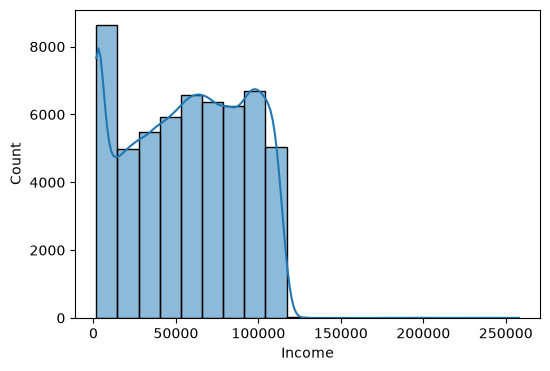

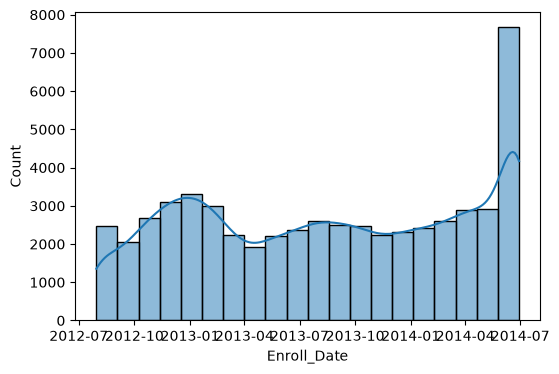

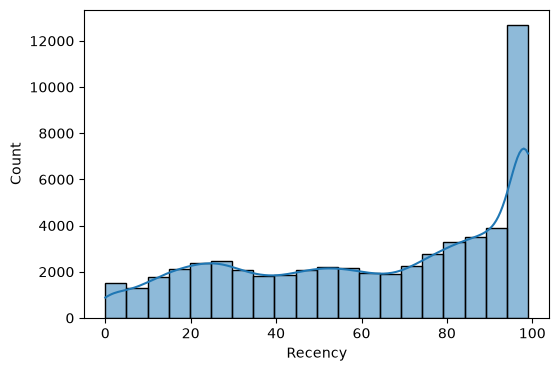

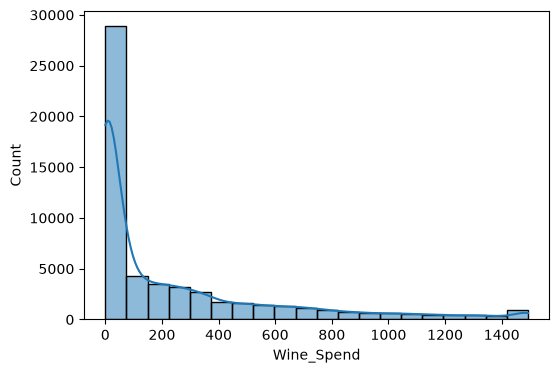

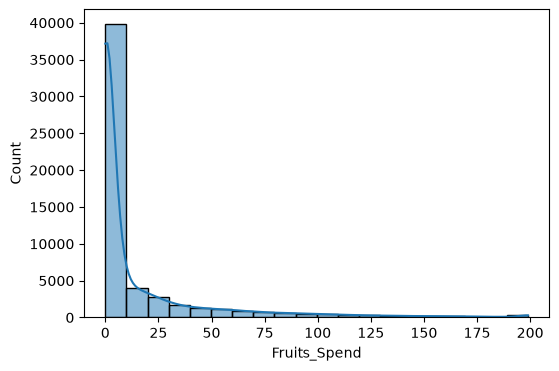

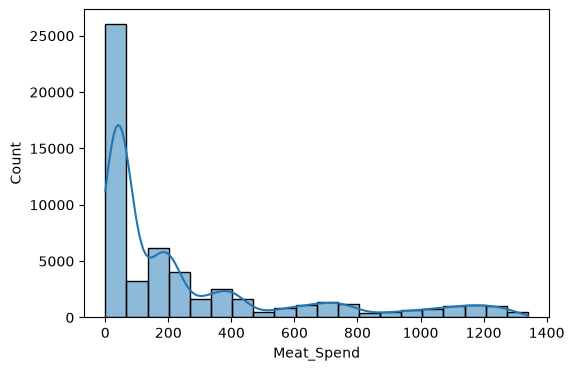

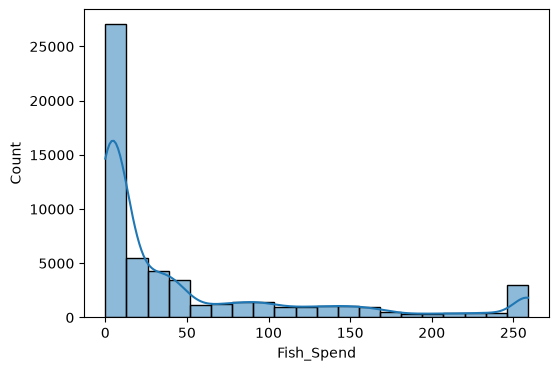

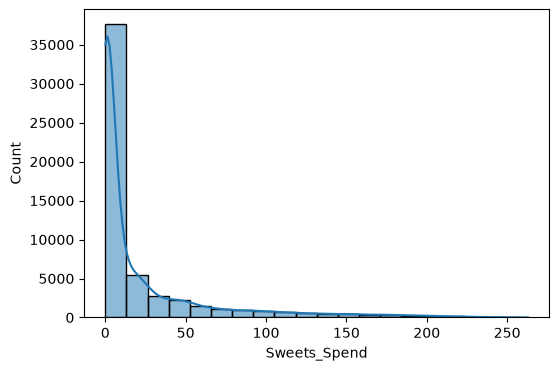

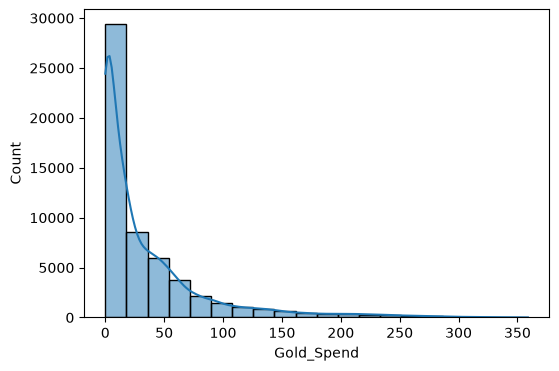

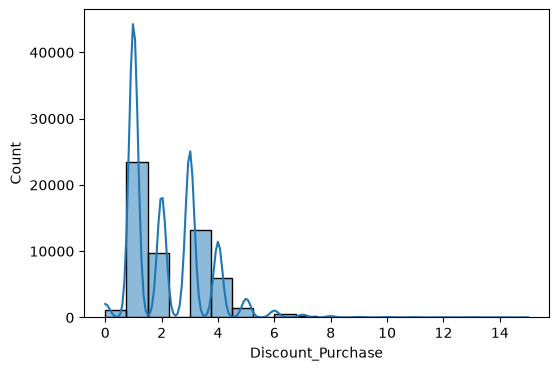

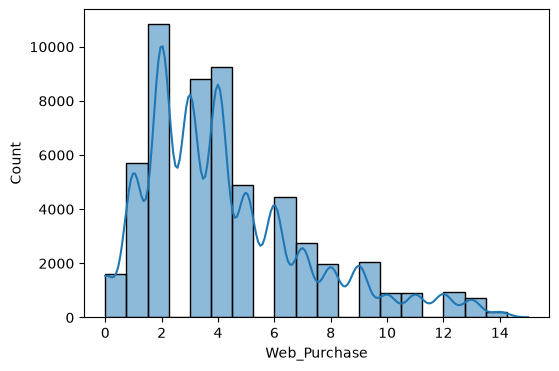

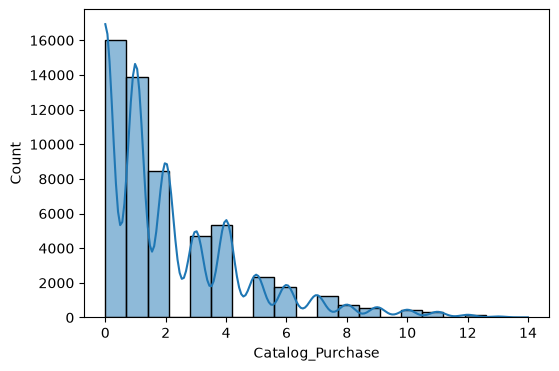

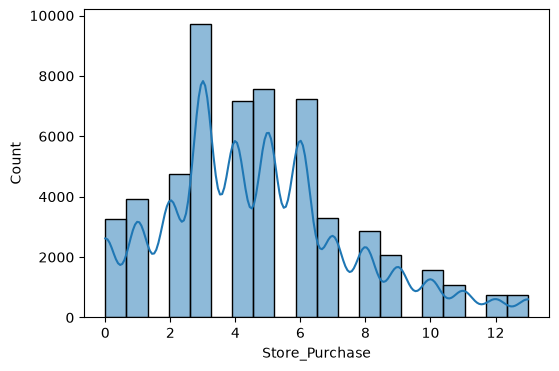

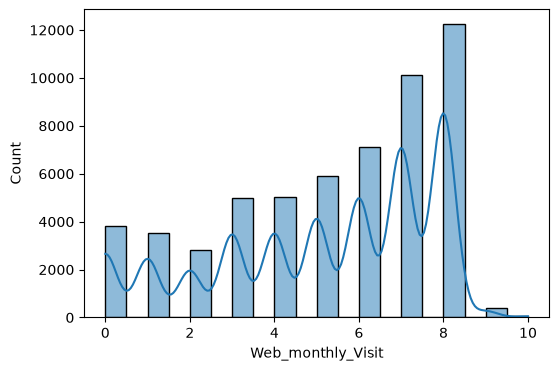

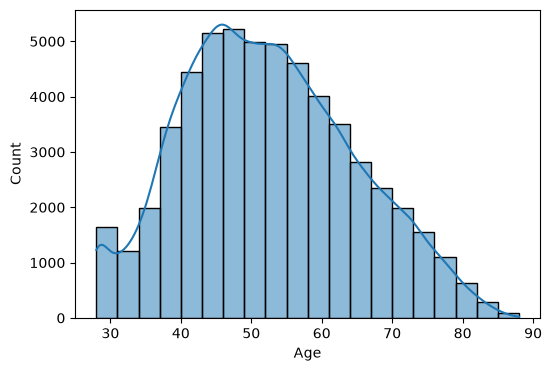

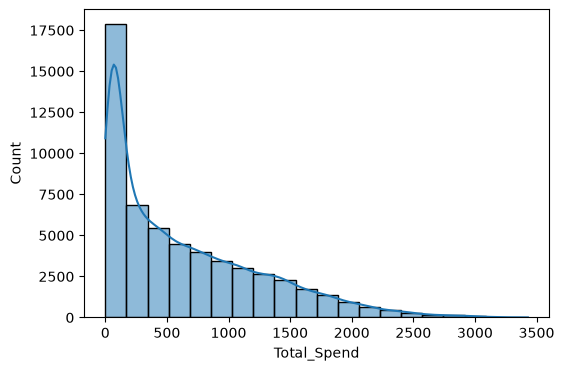

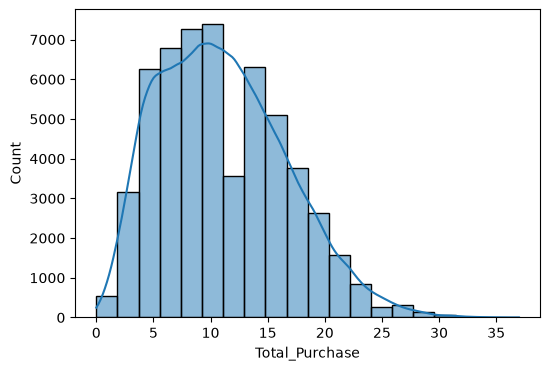

In [30]:
numaric_columns = ['Income', 'Enroll_Date', 'Recency', 'Wine_Spend', 'Fruits_Spend', 'Meat_Spend',
                    'Fish_Spend', 'Sweets_Spend', 'Gold_Spend','Discount_Purchase', 'Web_Purchase', 
                    'Catalog_Purchase','Store_Purchase', 'Web_monthly_Visit', 'Age',
                    'Total_Spend','Total_Purchase']

for col in numaric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(marketing_campaign[col],kde = True,bins = 20)

In [31]:
marketing_campaign.describe()

,ID,Year_Birth,Income,Kids,Teen,Enroll_Date,Recency,Wine_Spend,Fruits_Spend,Meat_Spend,...,Web_monthly_Visit,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,children,Age,Total_Spend,Total_Purchase
count,5.600000e+04,56000.000000,56000.000000,56000.000000,56000.000000,56000,56000.000000,56000.000000,56000.000000,56000.000000,...,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000
mean,8.389352e+06,1971.666696,57252.189521,0.539911,0.362143,2013-08-15 07:30:18.514285,63.221107,246.981482,16.152661,268.294018,...,5.170107,0.062393,0.056821,0.045661,0.134446,0.014411,0.902054,52.333304,640.334571,11.066054
min,3.600000e+01,1936.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,28.000000,0.000000,0.000000
25%,4.187372e+06,1963.000000,28252.025000,0.000000,0.000000,2013-01-24 00:00:00,35.000000,0.000000,0.000000,42.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.000000,103.000000,7.000000
50%,8.383784e+06,1973.000000,58838.550000,1.000000,0.000000,2013-08-19 00:00:00,71.000000,64.000000,0.000000,107.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,51.000000,441.500000,11.000000
75%,1.258576e+07,1981.000000,86930.650000,1.000000,1.000000,2014-03-10 00:00:00,93.000000,353.000000,15.000000,363.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,61.000000,1020.000000,15.000000
max,1.677716e+07,1996.000000,258027.500000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1341.000000,...,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,88.000000,3431.000000,37.000000
std,4.844638e+06,12.211066,34307.247999,0.521349,0.510567,NaN,31.157066,358.569481,33.931463,342.165712,...,2.555911,0.241870,0.231503,0.208750,0.341134,0.119178,0.739888,12.211066,622.643744,5.561779


# find outliers 


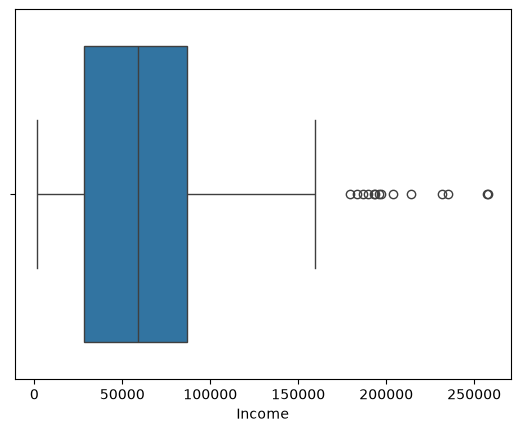

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Income'])
plt.show()


In [33]:
# 1. Calculate quartiles in income column
Q1 = marketing_campaign['Income'].quantile(0.25)
Q3 = marketing_campaign['Income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Income'] < lower_bound) | (marketing_campaign['Income'] > upper_bound)]
print(outliers)


             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
9973    4447366        1968       Basic       Together  213924.7     0     0   
11587   6633517        1991  Graduation         Single  231774.1     1     1   
21388   9169447        1984    Doctoral         Single  193497.9     0     0   
22047  10447992        1974  Graduation        Married  183504.5     1     1   
24935  15118576        1968      Master         Single  193007.6     1     0   
28149   4585031        1949      Master       Together  179550.9     1     0   
29541   6595146        1974  Graduation       Together  197257.7     0     0   
31526  14596919        1982      Master       Together  186727.6     1     0   
32030  10382905        1964  Graduation        Married  203999.1     0     0   
32846  11781883        1948  Graduation     Unattached  257317.4     0     1   
34310  15094458        1958      Master       Together  235075.0     0     0   
45829  16489272        1984  Graduation 

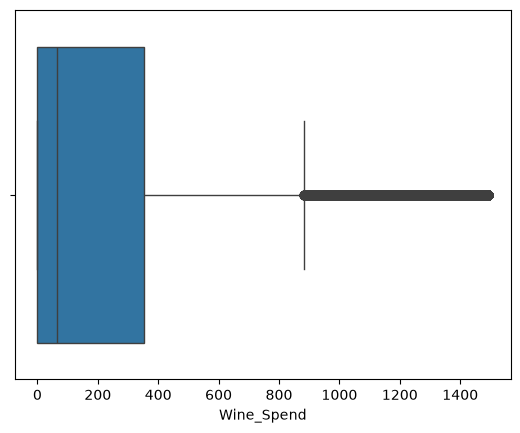

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Wine_Spend'])
plt.show()

In [35]:
# 1. Calculate quartiles in wine spend column
Q1 = marketing_campaign['Wine_Spend'].quantile(0.25)
Q3 = marketing_campaign['Wine_Spend'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Wine_Spend'] < lower_bound) | (marketing_campaign['Wine_Spend'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
2      13664263        1978  Graduation        Married   98584.6     0     0   
11       923176        1965      Master       Together  104661.2     0     1   
53     15452824        1995    Doctoral         Single   93350.4     0     0   
73     15304690        1957  Graduation     Unattached   79149.7     0     0   
94      6757971        1969  Graduation     Unattached  107698.7     0     1   
...         ...         ...         ...            ...       ...   ...   ...   
55924  11149431        1958  Graduation     Unattached   72260.9     0     0   
55928   2855921        1974    Doctoral       Together  116140.0     0     0   
55944   2935310        1951  Graduation         Single   95541.4     0     0   
55966   7635412        1960  Graduation        Married  114410.3     0     1   
55994   4362932        1969  Graduation     Unattached  111784.5     0     0   

      Enroll_Date  Recency  Wine_Spend 

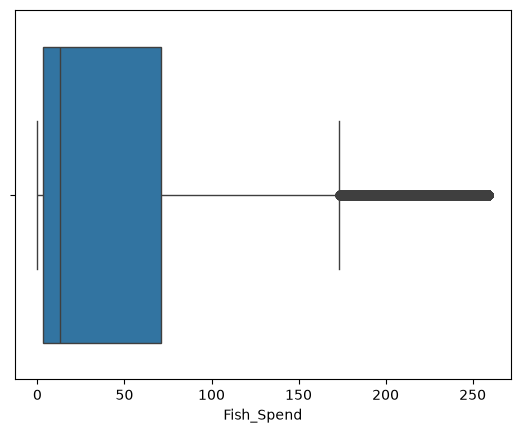

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Fish_Spend'])
plt.show()

In [37]:
# 1. Calculate quartiles in fish spend column
Q1 = marketing_campaign['Fish_Spend'].quantile(0.25)
Q3 = marketing_campaign['Fish_Spend'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Fish_Spend'] < lower_bound) | (marketing_campaign['Fish_Spend'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
4      15815139        1981  Graduation     Unattached   52784.2     1     1   
6       2330269        1960       Basic     Unattached  111080.3     0     0   
11       923176        1965      Master       Together  104661.2     0     1   
18      9413456        1979  Graduation         Single   47610.5     0     0   
30      9754902        1956      Master        Married   65172.4     0     0   
...         ...         ...         ...            ...       ...   ...   ...   
55956   4800704        1969  Graduation     Unattached  107611.2     1     1   
55966   7635412        1960  Graduation        Married  114410.3     0     1   
55967   4231377        1989  Graduation     Unattached   97391.7     1     0   
55970   6800586        1983      Master       Together  116902.9     0     0   
55972   9982309        1970  Graduation         Single   81984.9     0     0   

      Enroll_Date  Recency  Wine_Spend 

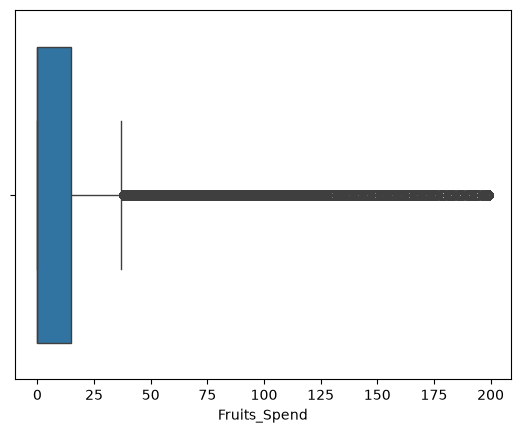

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Fruits_Spend'])
plt.show()

In [39]:
# 1. Calculate quartiles in fruits spend column
Q1 = marketing_campaign['Fruits_Spend'].quantile(0.25)
Q3 = marketing_campaign['Fruits_Spend'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Fruits_Spend'] < lower_bound) | (marketing_campaign['Fruits_Spend'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
6       2330269        1960       Basic     Unattached  111080.3     0     0   
32     15145895        1982    Doctoral     Unattached   92441.0     0     1   
34      3620143        1987      Master       Together  107197.9     0     0   
47      4443100        1945      Master        Married   54018.1     0     0   
59     15464104        1967    Doctoral     Unattached   96840.7     0     0   
...         ...         ...         ...            ...       ...   ...   ...   
55968    768292        1957       Basic       Together   76577.1     0     0   
55970   6800586        1983      Master       Together  116902.9     0     0   
55971  15064143        1968    Doctoral     Unattached  108175.6     0     0   
55981   2415112        1969    Doctoral     Unattached   48248.9     0     1   
55994   4362932        1969  Graduation     Unattached  111784.5     0     0   

      Enroll_Date  Recency  Wine_Spend 

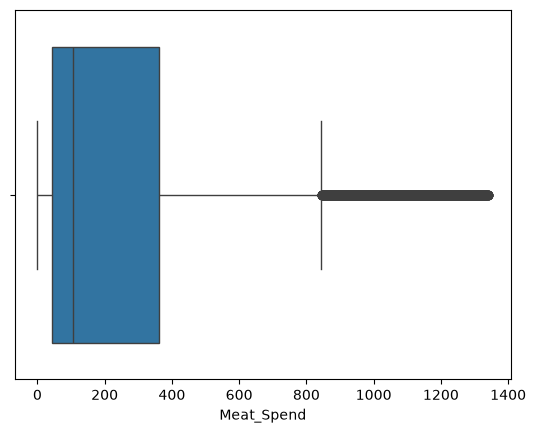

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Meat_Spend'])
plt.show()

In [41]:
# 1. Calculate quartiles in meat spend column
Q1 = marketing_campaign['Meat_Spend'].quantile(0.25)
Q3 = marketing_campaign['Meat_Spend'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Meat_Spend'] < lower_bound) | (marketing_campaign['Meat_Spend'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
28     13912972        1960  Graduation        Married   90351.9     0     0   
30      9754902        1956      Master        Married   65172.4     0     0   
31      6167587        1966  Graduation       Together  105043.4     1     0   
34      3620143        1987      Master       Together  107197.9     0     0   
39     16438440        1983    Doctoral       Together   99387.4     1     0   
...         ...         ...         ...            ...       ...   ...   ...   
55966   7635412        1960  Graduation        Married  114410.3     0     1   
55968    768292        1957       Basic       Together   76577.1     0     0   
55970   6800586        1983      Master       Together  116902.9     0     0   
55976  12207999        1946      Master       Together   17985.1     1     1   
55982    485962        1983  Graduation     Unattached   70842.8     1     1   

      Enroll_Date  Recency  Wine_Spend 

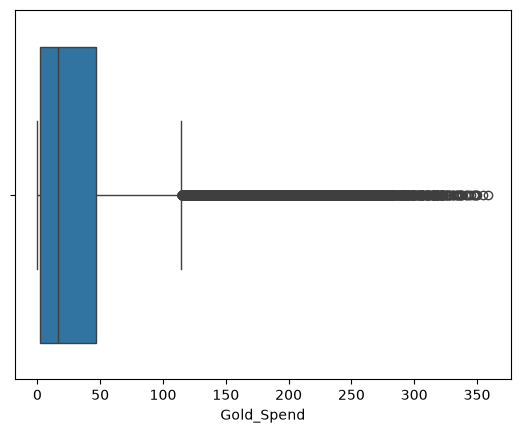

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Gold_Spend'])
plt.show()

In [43]:
# 1. Calculate quartiles in gold spend column
Q1 = marketing_campaign['Gold_Spend'].quantile(0.25)
Q3 = marketing_campaign['Gold_Spend'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Gold_Spend'] < lower_bound) | (marketing_campaign['Gold_Spend'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
2      13664263        1978  Graduation        Married   98584.6     0     0   
6       2330269        1960       Basic     Unattached  111080.3     0     0   
18      9413456        1979  Graduation         Single   47610.5     0     0   
31      6167587        1966  Graduation       Together  105043.4     1     0   
38     15626087        1966    Doctoral     Unattached   84247.4     0     1   
...         ...         ...         ...            ...       ...   ...   ...   
55901  12802715        1984      Master       Together   79796.9     0     0   
55928   2855921        1974    Doctoral       Together  116140.0     0     0   
55929   5251129        1979      Master        Married   47392.0     1     0   
55957   8033563        1973  Graduation     Unattached   90102.2     0     1   
55968    768292        1957       Basic       Together   76577.1     0     0   

      Enroll_Date  Recency  Wine_Spend 

In [44]:
# 1. Calculate quartiles in total spend column
Q1 = marketing_campaign['Total_Spend'].quantile(0.25)
Q3 = marketing_campaign['Total_Spend'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Total_Spend'] < lower_bound) | (marketing_campaign['Total_Spend'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
53     15452824        1995    Doctoral         Single   93350.4     0     0   
94      6757971        1969  Graduation     Unattached  107698.7     0     1   
145     1040479        1976      Master         Single   88972.5     0     1   
177     4813177        1971      Master         Single   93053.2     0     1   
206    13061321        1959  Graduation        Married  112371.2     0     0   
...         ...         ...         ...            ...       ...   ...   ...   
55645   4001860        1956    Doctoral     Unattached  102573.8     1     0   
55771   8436046        1945  Graduation        Married   95998.9     0     0   
55924  11149431        1958  Graduation     Unattached   72260.9     0     0   
55928   2855921        1974    Doctoral       Together  116140.0     0     0   
55966   7635412        1960  Graduation        Married  114410.3     0     1   

      Enroll_Date  Recency  Wine_Spend 

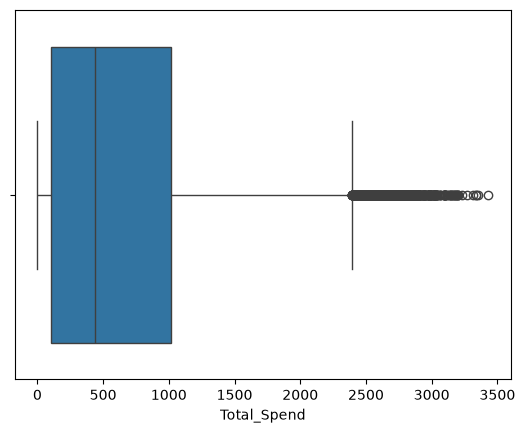

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Total_Spend'])
plt.show()

In [46]:
# 1. Calculate quartiles in sweets spend column
Q1 = marketing_campaign['Sweets_Spend'].quantile(0.25)
Q3 = marketing_campaign['Sweets_Spend'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Sweets_Spend'] < lower_bound) | (marketing_campaign['Sweets_Spend'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
2      13664263        1978  Graduation        Married   98584.6     0     0   
9       7068405        1968  Graduation       Together   54240.7     1     1   
18      9413456        1979  Graduation         Single   47610.5     0     0   
20     13545753        1982      Master       Together  101718.5     0     0   
28     13912972        1960  Graduation        Married   90351.9     0     0   
...         ...         ...         ...            ...       ...   ...   ...   
55964   9342809        1971  Graduation       Together   90039.8     0     1   
55966   7635412        1960  Graduation        Married  114410.3     0     1   
55968    768292        1957       Basic       Together   76577.1     0     0   
55971  15064143        1968    Doctoral     Unattached  108175.6     0     0   
55972   9982309        1970  Graduation         Single   81984.9     0     0   

      Enroll_Date  Recency  Wine_Spend 

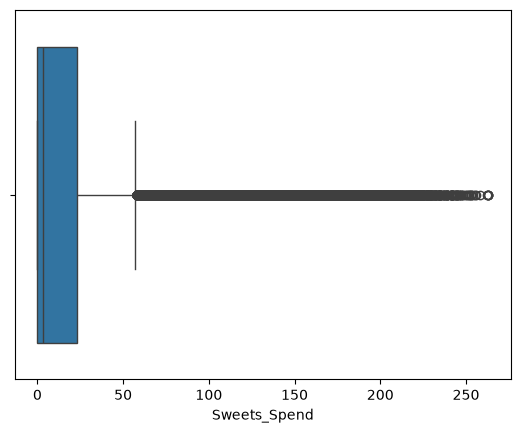

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Sweets_Spend'])
plt.show()

#handel outliers 


In [48]:
# 1. Calculate quartiles in web purchase column
Q1 = marketing_campaign['Web_Purchase'].quantile(0.25)
Q3 = marketing_campaign['Web_Purchase'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Web_Purchase'] < lower_bound) | (marketing_campaign['Web_Purchase'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
12      1271145        1975  Graduation       Together   56809.4     0     0   
22       943046        1959    Doctoral       Together  105458.3     1     1   
122     9183230        1977    Doctoral     Unattached   47915.9     0     0   
164     2464314        1972    Doctoral     Unattached  111173.9     0     0   
205     8513043        1978      Master         Single   63262.9     0     0   
...         ...         ...         ...            ...       ...   ...   ...   
55769   5550798        1959      Master     Unattached   74361.5     0     0   
55827  15977260        1957      Master       Together   86109.5     1     0   
55851   2411317        1995      Master       Together   77178.1     0     0   
55921   5406404        1982      Master     Unattached  111865.0     0     1   
55991   6592660        1985      Master         Single   54674.4     0     0   

      Enroll_Date  Recency  Wine_Spend 

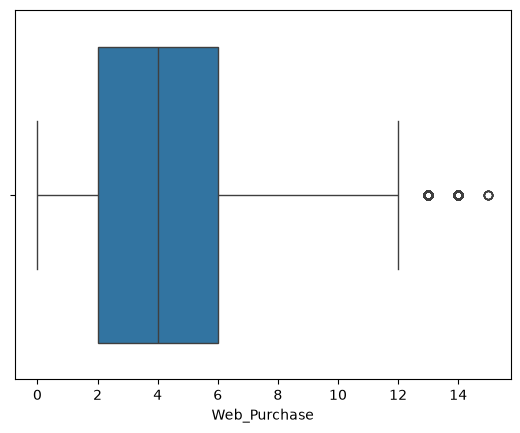

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Web_Purchase'])
plt.show()

In [50]:
# 1. Calculate quartiles in discount purchase column
Q1 = marketing_campaign['Discount_Purchase'].quantile(0.25)
Q3 = marketing_campaign['Discount_Purchase'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Discount_Purchase'] < lower_bound) | (marketing_campaign['Discount_Purchase'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
150     9394199        1964  Graduation     Unattached   74628.8     0     1   
236     9260420        1983    Doctoral     Unattached   86361.1     0     0   
256     3911870        1991    Doctoral         Single   42730.5     1     0   
640     3330554        1977  Graduation       Together   34532.0     0     1   
712    10510768        1996      Master         Single   58201.8     1     1   
...         ...         ...         ...            ...       ...   ...   ...   
55535  12641443        1953      Master         Single   70761.3     0     0   
55656   4252905        1958      Master        Married   68498.5     0     0   
55660   9216670        1988      Master        Married   15704.0     1     0   
55786  13299986        1996  Graduation     Unattached   93404.9     1     0   
55971  15064143        1968    Doctoral     Unattached  108175.6     0     0   

      Enroll_Date  Recency  Wine_Spend 

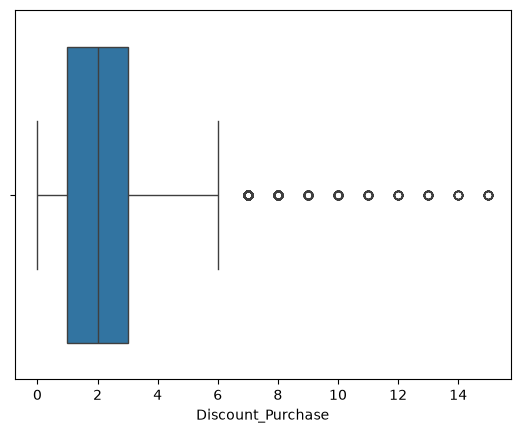

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Discount_Purchase'])
plt.show()

In [52]:
# 1. Calculate quartiles in catalog purchase column
Q1 = marketing_campaign['Catalog_Purchase'].quantile(0.25)
Q3 = marketing_campaign['Catalog_Purchase'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Catalog_Purchase'] < lower_bound) | (marketing_campaign['Catalog_Purchase'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
24     16663364        1961       Basic     Unattached   16379.1     0     0   
31      6167587        1966  Graduation       Together  105043.4     1     0   
48     12284547        1969    Doctoral     Unattached   97141.3     0     2   
54     13341014        1973  Graduation        Married   77256.3     1     2   
60      9798566        1971  Graduation     Unattached   48601.4     0     0   
...         ...         ...         ...            ...       ...   ...   ...   
55728   9347875        1951  Graduation         Single   65703.6     1     0   
55732    240490        1974  Graduation       Together   94769.1     0     0   
55924  11149431        1958  Graduation     Unattached   72260.9     0     0   
55925   8828800        1964  Graduation     Unattached   99705.2     0     0   
55994   4362932        1969  Graduation     Unattached  111784.5     0     0   

      Enroll_Date  Recency  Wine_Spend 

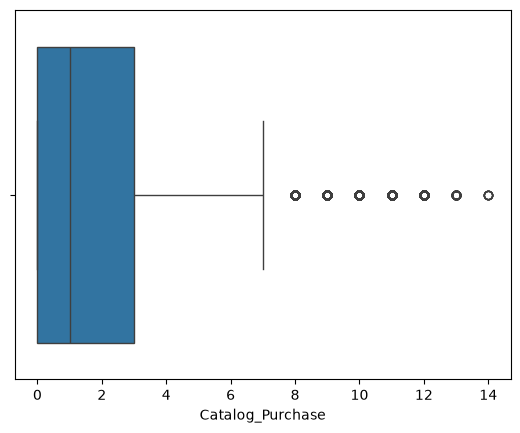

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Catalog_Purchase'])
plt.show()

In [54]:
# 1. Calculate quartiles in discount purchase column
Q1 = marketing_campaign['Discount_Purchase'].quantile(0.25)
Q3 = marketing_campaign['Discount_Purchase'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Discount_Purchase'] < lower_bound) | (marketing_campaign['Discount_Purchase'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
150     9394199        1964  Graduation     Unattached   74628.8     0     1   
236     9260420        1983    Doctoral     Unattached   86361.1     0     0   
256     3911870        1991    Doctoral         Single   42730.5     1     0   
640     3330554        1977  Graduation       Together   34532.0     0     1   
712    10510768        1996      Master         Single   58201.8     1     1   
...         ...         ...         ...            ...       ...   ...   ...   
55535  12641443        1953      Master         Single   70761.3     0     0   
55656   4252905        1958      Master        Married   68498.5     0     0   
55660   9216670        1988      Master        Married   15704.0     1     0   
55786  13299986        1996  Graduation     Unattached   93404.9     1     0   
55971  15064143        1968    Doctoral     Unattached  108175.6     0     0   

      Enroll_Date  Recency  Wine_Spend 

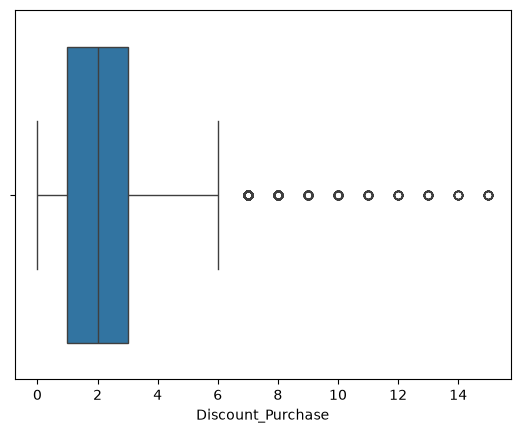

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Discount_Purchase'])
plt.show()

In [56]:
# 1. Calculate quartiles in discount purchase column
Q1 = marketing_campaign['Discount_Purchase'].quantile(0.25)
Q3 = marketing_campaign['Discount_Purchase'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Discount_Purchase'] < lower_bound) | (marketing_campaign['Discount_Purchase'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
150     9394199        1964  Graduation     Unattached   74628.8     0     1   
236     9260420        1983    Doctoral     Unattached   86361.1     0     0   
256     3911870        1991    Doctoral         Single   42730.5     1     0   
640     3330554        1977  Graduation       Together   34532.0     0     1   
712    10510768        1996      Master         Single   58201.8     1     1   
...         ...         ...         ...            ...       ...   ...   ...   
55535  12641443        1953      Master         Single   70761.3     0     0   
55656   4252905        1958      Master        Married   68498.5     0     0   
55660   9216670        1988      Master        Married   15704.0     1     0   
55786  13299986        1996  Graduation     Unattached   93404.9     1     0   
55971  15064143        1968    Doctoral     Unattached  108175.6     0     0   

      Enroll_Date  Recency  Wine_Spend 

In [57]:
# 1. Calculate quartiles in store purchase column
Q1 = marketing_campaign['Store_Purchase'].quantile(0.25)
Q3 = marketing_campaign['Store_Purchase'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Store_Purchase'] < lower_bound) | (marketing_campaign['Store_Purchase'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
3      16164787        1976  Graduation        Married   74031.5     1     0   
22       943046        1959    Doctoral       Together  105458.3     1     1   
48     12284547        1969    Doctoral     Unattached   97141.3     0     2   
68        82023        1974  Graduation         Single  110837.1     0     0   
137     6893843        1993    Doctoral     Unattached  108350.6     0     1   
...         ...         ...         ...            ...       ...   ...   ...   
55883   6531559        1996  Graduation     Unattached    8161.7     1     1   
55906   9308604        1985  Graduation     Unattached   27335.2     1     1   
55922  14039368        1942      Master       Together   80719.4     0     0   
55926   2589253        1986  Graduation       Together  106288.9     0     0   
55970   6800586        1983      Master       Together  116902.9     0     0   

      Enroll_Date  Recency  Wine_Spend 

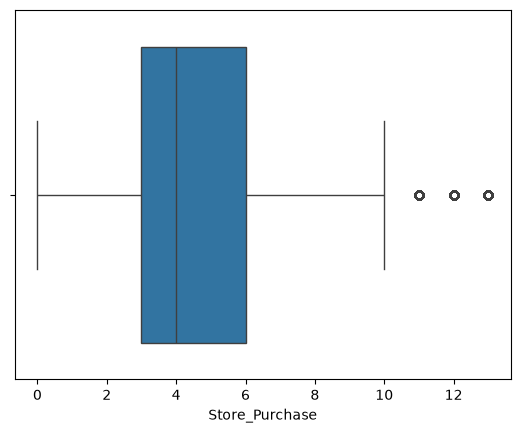

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Store_Purchase'])
plt.show()

In [59]:
# 1. Calculate quartiles in total spend column
Q1 = marketing_campaign['Total_Spend'].quantile(0.25)
Q3 = marketing_campaign['Total_Spend'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Total_Spend'] < lower_bound) | (marketing_campaign['Total_Spend'] > upper_bound)]
print(outliers)

             ID  Year_Birth   Education Marital_Status    Income  Kids  Teen  \
53     15452824        1995    Doctoral         Single   93350.4     0     0   
94      6757971        1969  Graduation     Unattached  107698.7     0     1   
145     1040479        1976      Master         Single   88972.5     0     1   
177     4813177        1971      Master         Single   93053.2     0     1   
206    13061321        1959  Graduation        Married  112371.2     0     0   
...         ...         ...         ...            ...       ...   ...   ...   
55645   4001860        1956    Doctoral     Unattached  102573.8     1     0   
55771   8436046        1945  Graduation        Married   95998.9     0     0   
55924  11149431        1958  Graduation     Unattached   72260.9     0     0   
55928   2855921        1974    Doctoral       Together  116140.0     0     0   
55966   7635412        1960  Graduation        Married  114410.3     0     1   

      Enroll_Date  Recency  Wine_Spend 

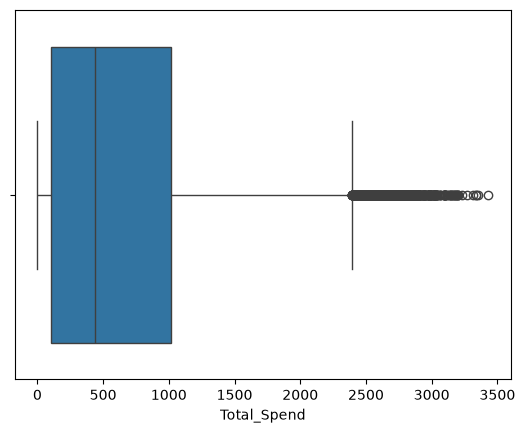

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Total_Spend'])
plt.show()

In [61]:
# 1. Calculate quartiles in recency column
Q1 = marketing_campaign['Recency'].quantile(0.25)
Q3 = marketing_campaign['Recency'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Extract the exact rows containing the outliers
outliers = marketing_campaign[(marketing_campaign['Recency'] < lower_bound) | (marketing_campaign['Recency'] > upper_bound)]
print(outliers)

Empty DataFrame
Columns: [ID, Year_Birth, Education, Marital_Status, Income, Kids, Teen, Enroll_Date, Recency, Wine_Spend, Fruits_Spend, Meat_Spend, Fish_Spend, Sweets_Spend, Gold_Spend, Discount_Purchase, Web_Purchase, Catalog_Purchase, Store_Purchase, Web_monthly_Visit, AcceptedCmp3, AcceptedCmp4, AcceptedCmp5, AcceptedCmp1, AcceptedCmp2, Response, Complain, Resident, children, Age, Total_Spend, Total_Purchase]
Index: []

[0 rows x 32 columns]


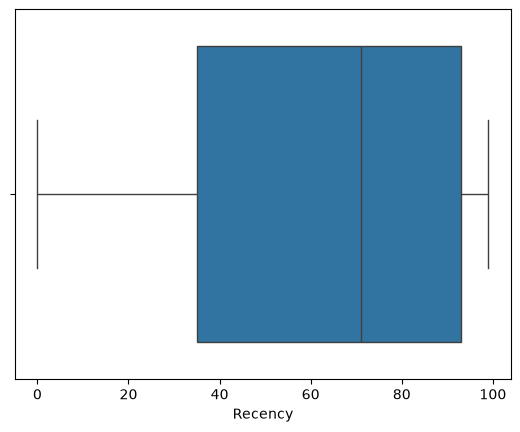

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creates a box plot to expose visual outliers
sns.boxplot(x=marketing_campaign['Recency'])
plt.show()

In [63]:
marketing_campaign.head(20)

,ID,Year_Birth,Education,Marital_Status,Income,Kids,Teen,Enroll_Date,Recency,Wine_Spend,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Resident,children,Age,Total_Spend,Total_Purchase
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,0,0,0,False,False,Spain,1,39,69,10
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,0,0,0,False,False,Spain,2,49,39,3
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,0,0,0,False,False,Australia,0,46,1512,9
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,0,0,0,False,False,Spain,1,48,478,15
4,15815139,1981,Graduation,Unattached,52784.2,1,1,2014-05-20,0,30,...,0,0,0,False,False,Canada,2,43,330,8
5,7194200,1977,Master,Married,36353.5,1,0,2014-03-28,99,0,...,0,0,0,False,False,Canada,1,47,132,10
6,2330269,1960,Basic,Unattached,111080.3,0,0,2013-08-05,14,152,...,0,0,0,False,False,Germany,0,64,843,14
7,12076936,1996,Doctoral,Unattached,55986.3,1,1,2014-02-16,52,80,...,0,0,0,False,False,India,2,28,98,10
8,13223357,1964,Master,Single,67793.7,1,0,2013-01-28,11,5,...,0,0,0,False,False,Saudi Arabia,1,60,91,8
9,7068405,1968,Graduation,Together,54240.7,1,1,2014-06-29,69,87,...,0,1,0,False,False,USA,2,56,251,3


In [64]:
# Define the bin edges and corresponding category labels
bins = [0, 35, 55, np.inf]
labels = ["young", "middle age", "senior citizen"]

# Create the Age_group column
marketing_campaign["Age_group"] = pd.cut(
    marketing_campaign["Age"], bins=bins, labels=labels, right=True
)

# Display the first few rows to verify
print(marketing_campaign[["Age", "Age_group"]].head())


   Age   Age_group
0   39  middle age
1   49  middle age
2   46  middle age
3   48  middle age
4   43  middle age


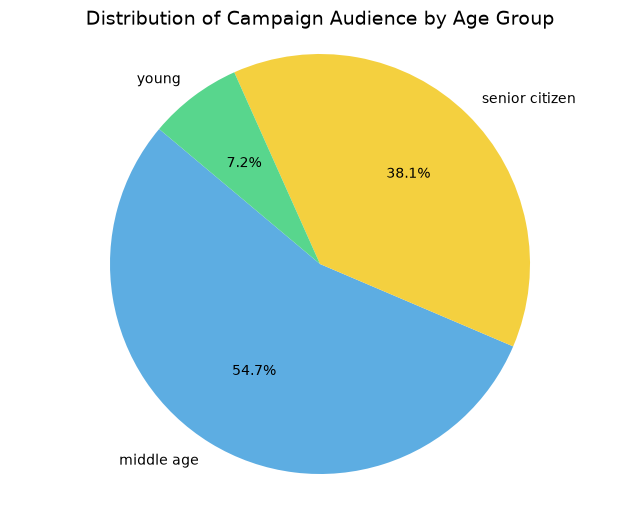

In [65]:
# Group the data by 'Age_group' and count the number of rows in each group
age_counts = marketing_campaign["Age_group"].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#5dade2", "#f4d03f", "#58d68d"],
)

# Add title and ensure layout is clean
plt.title("Distribution of Campaign Audience by Age Group", fontsize=14)
plt.axis("equal")  # Equal aspect ratio ensures that pie is drawn as a circle.

# Display the plot
plt.show()


In [66]:
# Define the bin edges and corresponding category labels
bins = [0, 50000, 100000, np.inf]
labels = ["low_income", "middle_income", "high_income"]

# Create the Income_group column
marketing_campaign["Income_group"] = pd.cut(
    marketing_campaign["Income"], bins=bins, labels=labels, right=True
)

# Display the first few rows to verify
print(marketing_campaign[["Income", "Income_group"]].head())

    Income   Income_group
0  59011.7  middle_income
1   1730.0     low_income
2  98584.6  middle_income
3  74031.5  middle_income
4  52784.2  middle_income


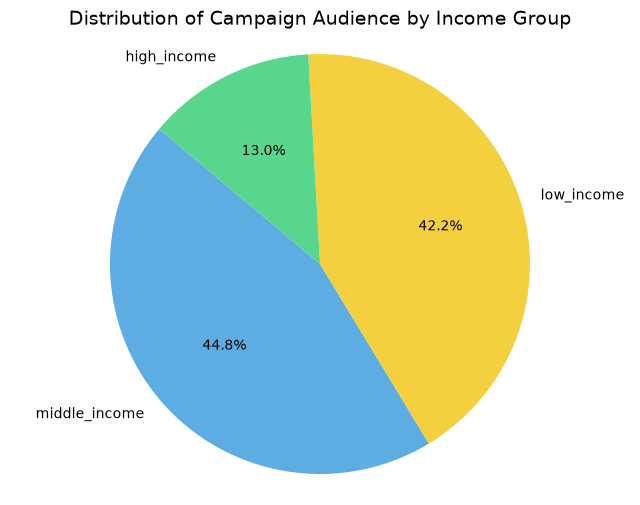

In [67]:
# Group the data by 'Income_group' and count the number of rows in each group
income_counts = marketing_campaign["Income_group"].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    income_counts,
    labels=income_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#5dade2", "#f4d03f", "#58d68d"],
)

# Add title and ensure layout is clean
plt.title("Distribution of Campaign Audience by Income Group", fontsize=14)
plt.axis("equal")  # Equal aspect ratio ensures that pie is drawn as a circle.

# Display the plot
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_15820\3471233442.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


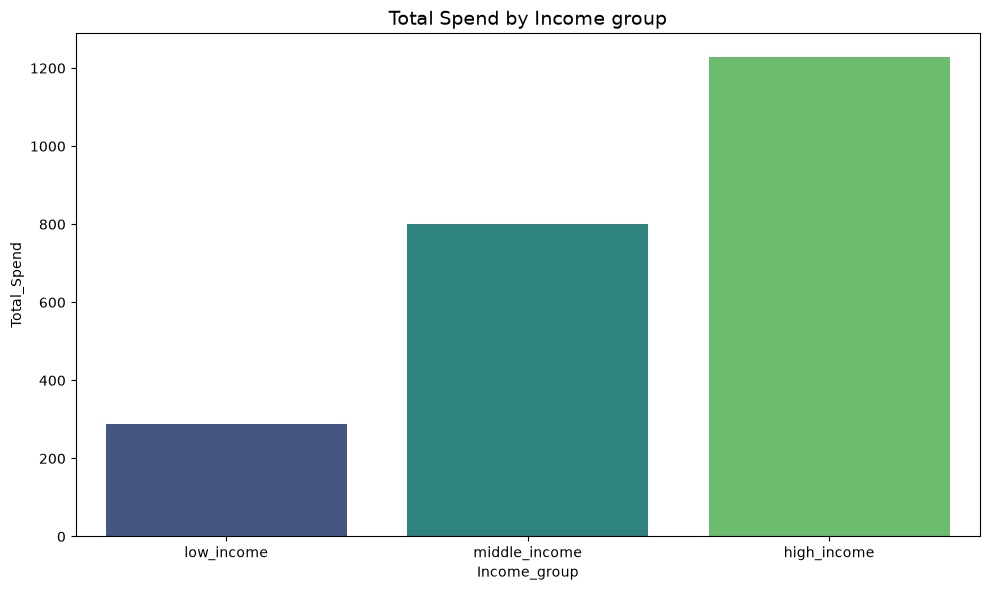

In [68]:

plt.figure(figsize=(10, 6))
sns.barplot(
    data=marketing_campaign,
    x=marketing_campaign["Income_group"],
    y=marketing_campaign["Total_Spend"],
    palette="viridis",
    errorbar=None,  # Remove this line if you want to see error bars/confidence intervals
)

plt.title("Total Spend by Income group", fontsize=14)
plt.tight_layout()
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_15820\141519221.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


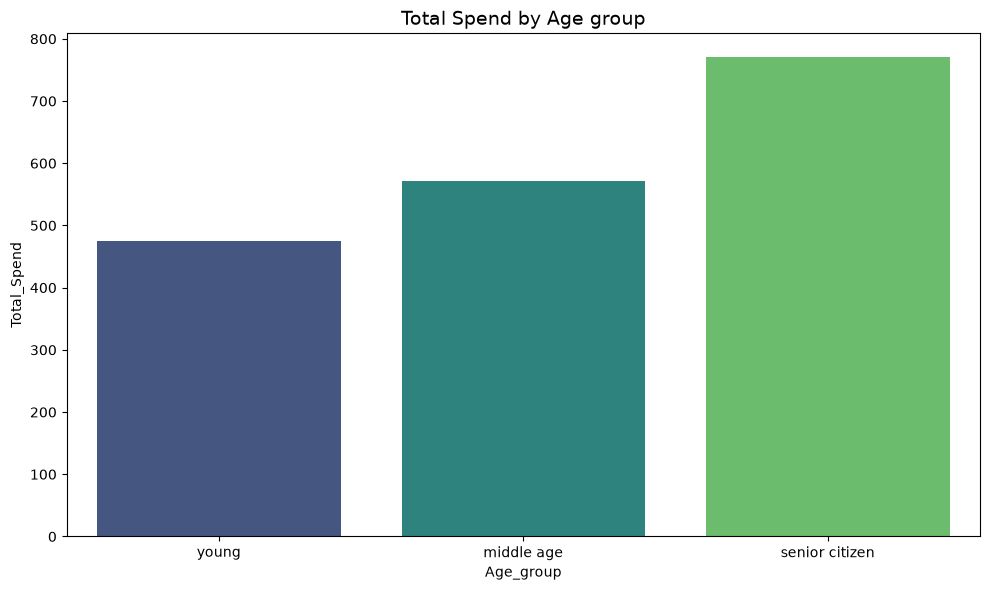

In [69]:

plt.figure(figsize=(10, 6))
sns.barplot(
    data=marketing_campaign,
    x=marketing_campaign["Age_group"],
    y=marketing_campaign["Total_Spend"],
    palette="viridis",
    errorbar=None,  # Remove this line if you want to see error bars/confidence intervals
)

plt.title("Total Spend by Age group", fontsize=14)
plt.tight_layout()
plt.show()

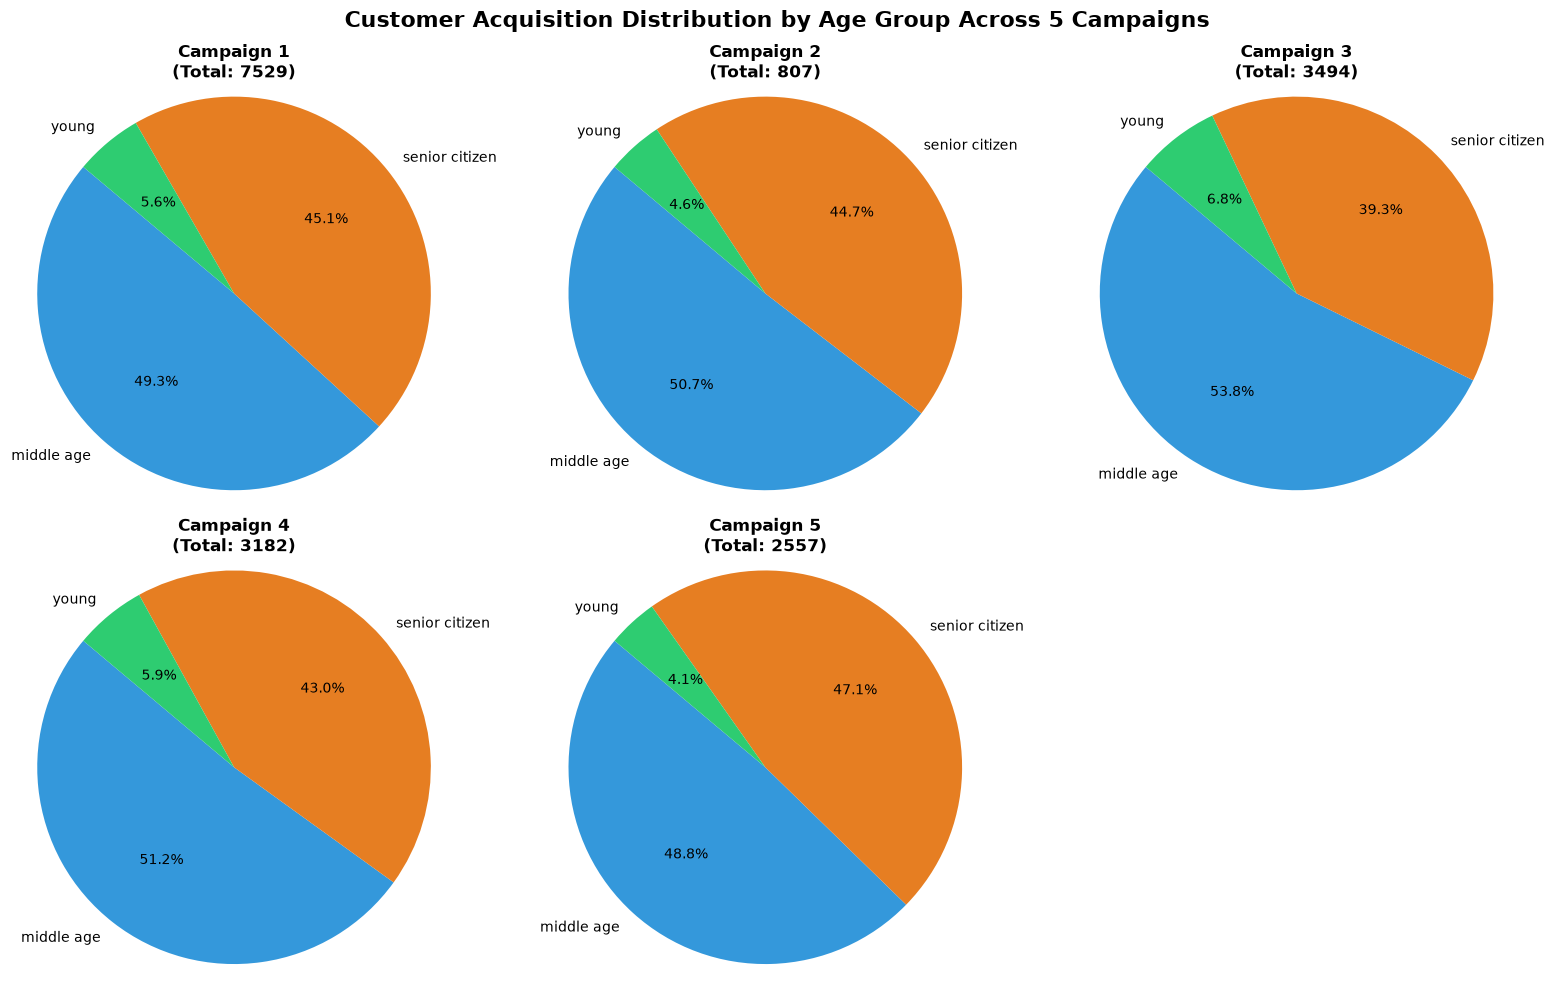

In [70]:
# 1. Define the columns representing your 5 campaigns
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
]
campaign_labels = ["Campaign 1", "Campaign 2", "Campaign 3", "Campaign 4", "Campaign 5"]

# 2. Setup a grid of 5 subplots (2 rows, 3 columns - leaving the last slot empty)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # Flatten to easily loop over them

colors = ["#3498db", "#e67e22", "#2ecc71"]  # Colors for Young, Middle Age, Senior

# 3. Loop through each campaign and plot its demographic breakdown
for i, col in enumerate(campaign_cols):
    # Filter dataset to only include customers acquired (accepted) by this specific campaign
    acquired_customers = marketing_campaign[marketing_campaign[col] == 1]

    # Count how many of these acquired customers fall into each age group
    age_counts = acquired_customers["Age_group"].value_counts()

    # Handle the edge case where a campaign might have 0 responses for a specific age group
    if age_counts.sum() == 0:
        axes[i].text(
            0.5,
            0.5,
            "No Customers Acquired",
            ha="center",
            va="center",
            fontsize=12,
            style="italic",
        )
        axes[i].set_title(campaign_labels[i], weight="bold", fontsize=12)
        axes[i].axis("off")
        continue

    # Plot individual pie chart on its designated subplot axis
    axes[i].pie(
        age_counts,
        labels=age_counts.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=colors,
        textprops={"fontsize": 10},
    )
    axes[i].set_title(
        f"{campaign_labels[i]}\n(Total: {age_counts.sum()})",
        weight="bold",
        fontsize=12,
    )
    axes[i].axis("equal")  # Keep it perfectly circular

# Hide the 6th empty subplot axes since we only have 5 campaigns
axes[5].axis("off")

# 4. Final adjustments and display
plt.suptitle(
    "Customer Acquisition Distribution by Age Group Across 5 Campaigns",
    fontsize=16,
    weight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()


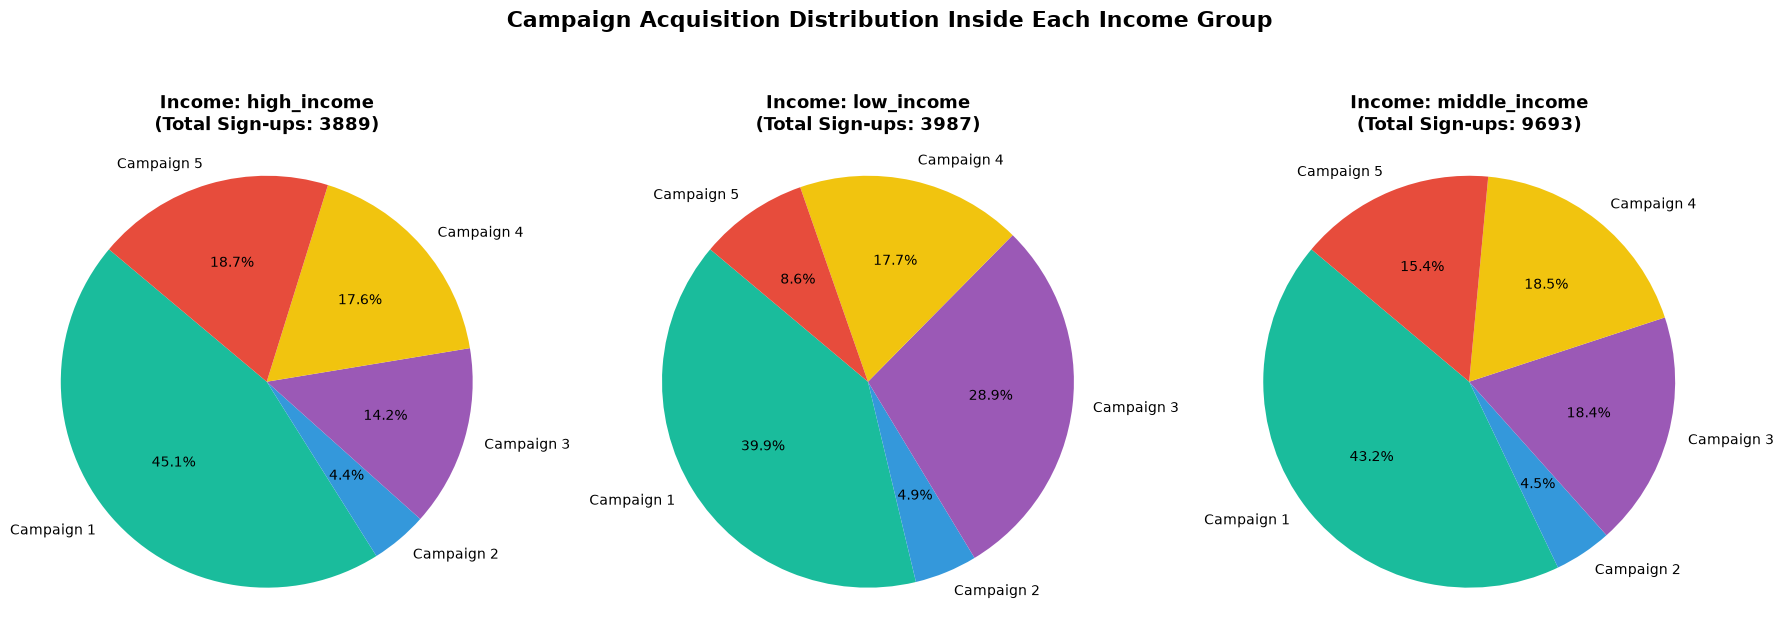

In [71]:
import matplotlib.pyplot as plt

# 1. Define the 5 campaign columns and text labels
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
]
campaign_labels = ["Campaign 1", "Campaign 2", "Campaign 3", "Campaign 4", "Campaign 5"]

# 2. Get the unique income groups present in your DataFrame
# (Assuming 'Income_Group' was generated in the previous step)
income_groups = marketing_campaign["Income_group"].dropna().unique()
income_groups = sorted(income_groups)  # Sort them chronologically/logically

# 3. Setup subplots grid (1 row, dynamically sized by number of income groups)
fig, axes = plt.subplots(1, len(income_groups), figsize=(6 * len(income_groups), 6))

# If there is only 1 group, wrap it in a list so the loop doesn't break
if len(income_groups) == 1:
    axes = [axes]

# Distinct color palette for the 5 individual campaigns
campaign_colors = ["#1abc9c", "#3498db", "#9b59b6", "#f1c40f", "#e74c3c"]

# 4. Loop through each income group and plot campaign distribution
for i, group in enumerate(income_groups):
    # Filter dataset for the specific income group segment
    group_data = marketing_campaign[marketing_campaign["Income_group"] == group]

    # Sum up successful acquisitions for each campaign inside this income group
    campaign_success_counts = group_data[campaign_cols].sum()

    # Handle edge cases where an entire segment has zero responses
    if campaign_success_counts.sum() == 0:
        axes[i].text(
            0.5,
            0.5,
            "No Campaigns Accepted",
            ha="center",
            va="center",
            fontsize=12,
            style="italic",
        )
        axes[i].set_title(f"Income Tier: {group}", weight="bold", fontsize=14)
        axes[i].axis("off")
        continue

    # Plot individual pie chart
    axes[i].pie(
        campaign_success_counts,
        labels=campaign_labels,
        autopct="%1.1f%%",
        startangle=140,
        colors=campaign_colors,
        textprops={"fontsize": 10},
    )
    axes[i].set_title(
        f"Income: {group}\n(Total Sign-ups: {int(campaign_success_counts.sum())})",
        weight="bold",
        fontsize=13,
    )
    axes[i].axis("equal")  # Keeps the pie perfectly circular

# 5. Overarching master title layout properties
plt.suptitle(
    "Campaign Acquisition Distribution Inside Each Income Group",
    fontsize=16,
    weight="bold",
    y=1.05,
)
plt.tight_layout()
plt.show()


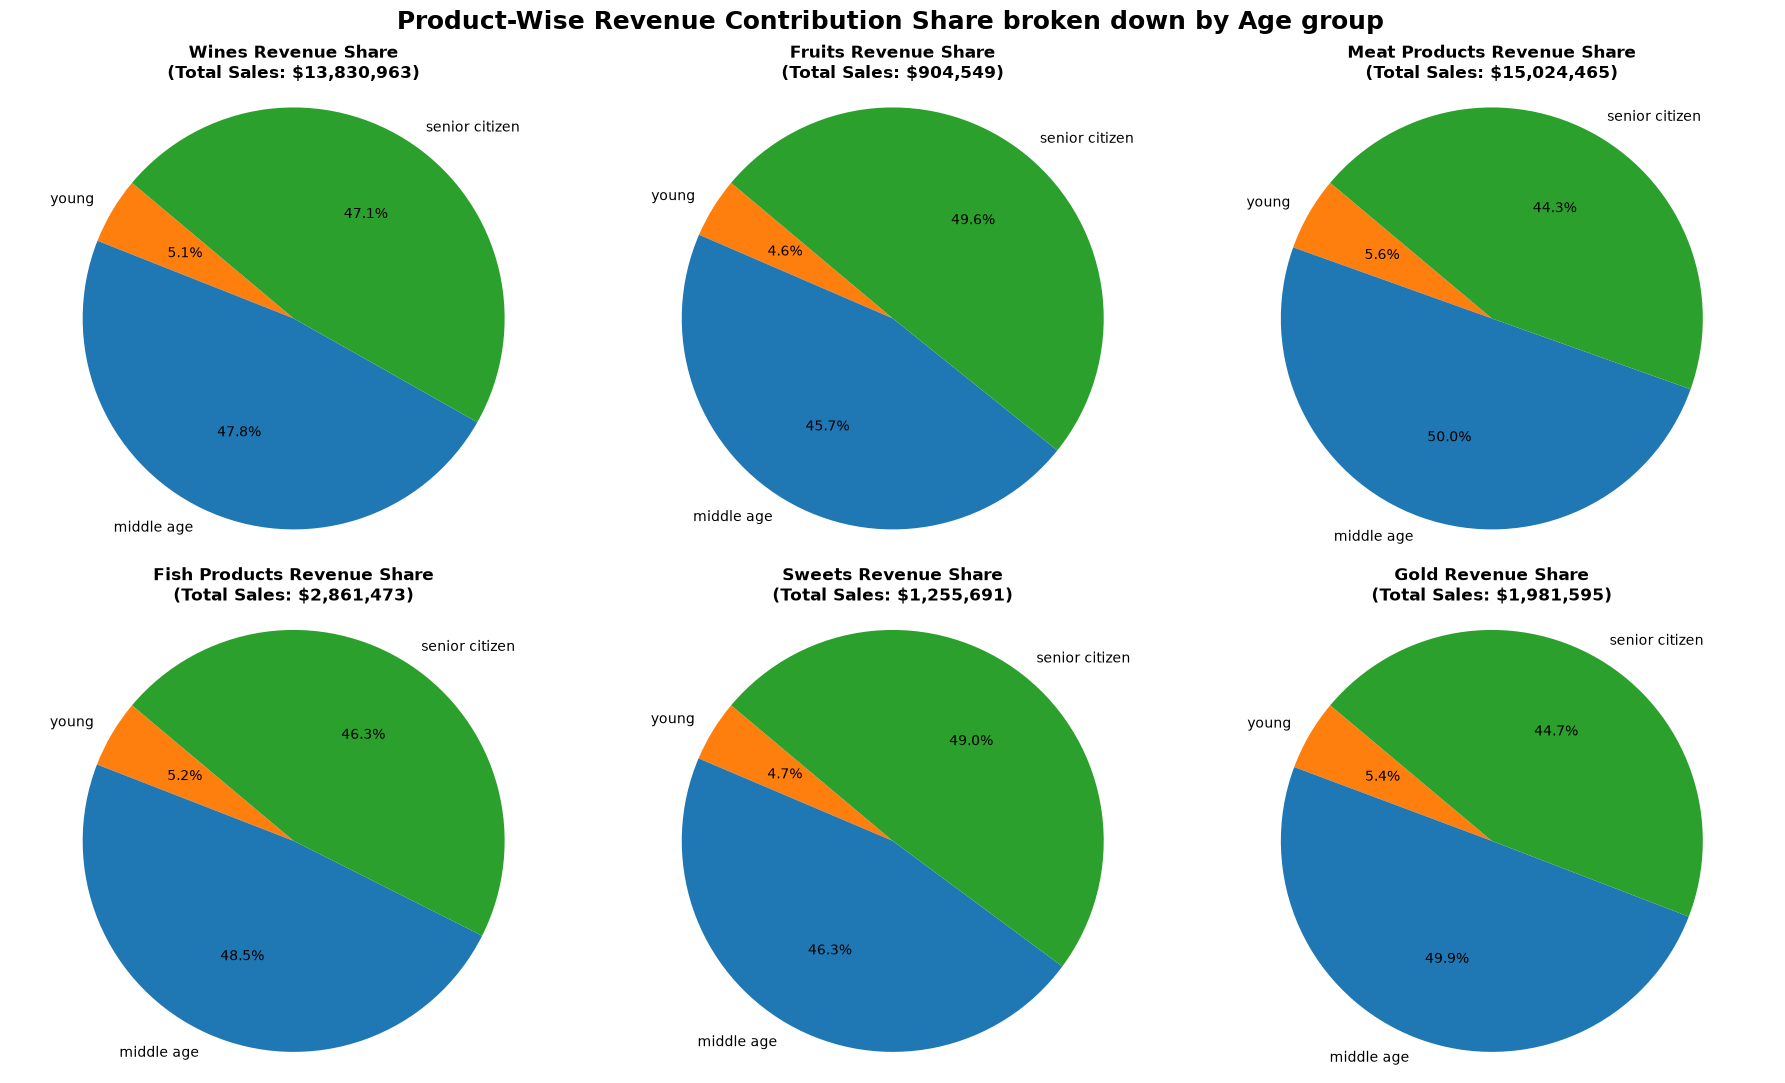

In [72]:
import matplotlib.pyplot as plt

# 1. Define the 6 individual product spending columns from the dataset
product_cols = [
    "Wine_Spend",
    "Fruits_Spend",
    "Meat_Spend",
    "Fish_Spend",
    "Sweets_Spend",
    "Gold_Spend",
]
product_labels = ["Wines", "Fruits", "Meat Products", "Fish Products", "Sweets", "Gold"]

# 2. CHOOSE YOUR DEMOGRAPHIC FILTER HERE: Change to "Income_Group" if desired
demographic_col = "Age_group"  # Alternative: "Income_Group"

# 3. Setup a clean 2x3 grid of subplots for the 6 products
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()  # Flatten the 2D grid matrix into a 1D loop list

# Visual color theme for the slices
colors = ["#ff7f0e", "#1f77b4", "#2ca02c", "#d62728", "#9467bd"]

# 4. Loop through each product and build its revenue contribution chart
for i, col in enumerate(product_cols):
    # Calculate the total revenue sum for this specific product grouped by your demographic
    product_revenue_mix = marketing_campaign.groupby(demographic_col, observed=False)[
        col
    ].sum()

    # Plot the pie chart for this specific product channel
    axes[i].pie(
        product_revenue_mix,
        labels=product_revenue_mix.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=colors[: len(product_revenue_mix)],
        textprops={"fontsize": 10},
    )

    # Title with the name of the product and its total overall revenue amount
    total_sales = product_revenue_mix.sum()
    axes[i].set_title(
        f"{product_labels[i]} Revenue Share\n(Total Sales: ${total_sales:,.0f})",
        weight="bold",
        fontsize=12,
    )
    axes[i].axis("equal")  # Maintain crisp circular geometry

# 5. Master layout properties and display configuration
plt.suptitle(
    f"Product-Wise Revenue Contribution Share broken down by {demographic_col.replace('_', ' ')}",
    fontsize=18,
    weight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()


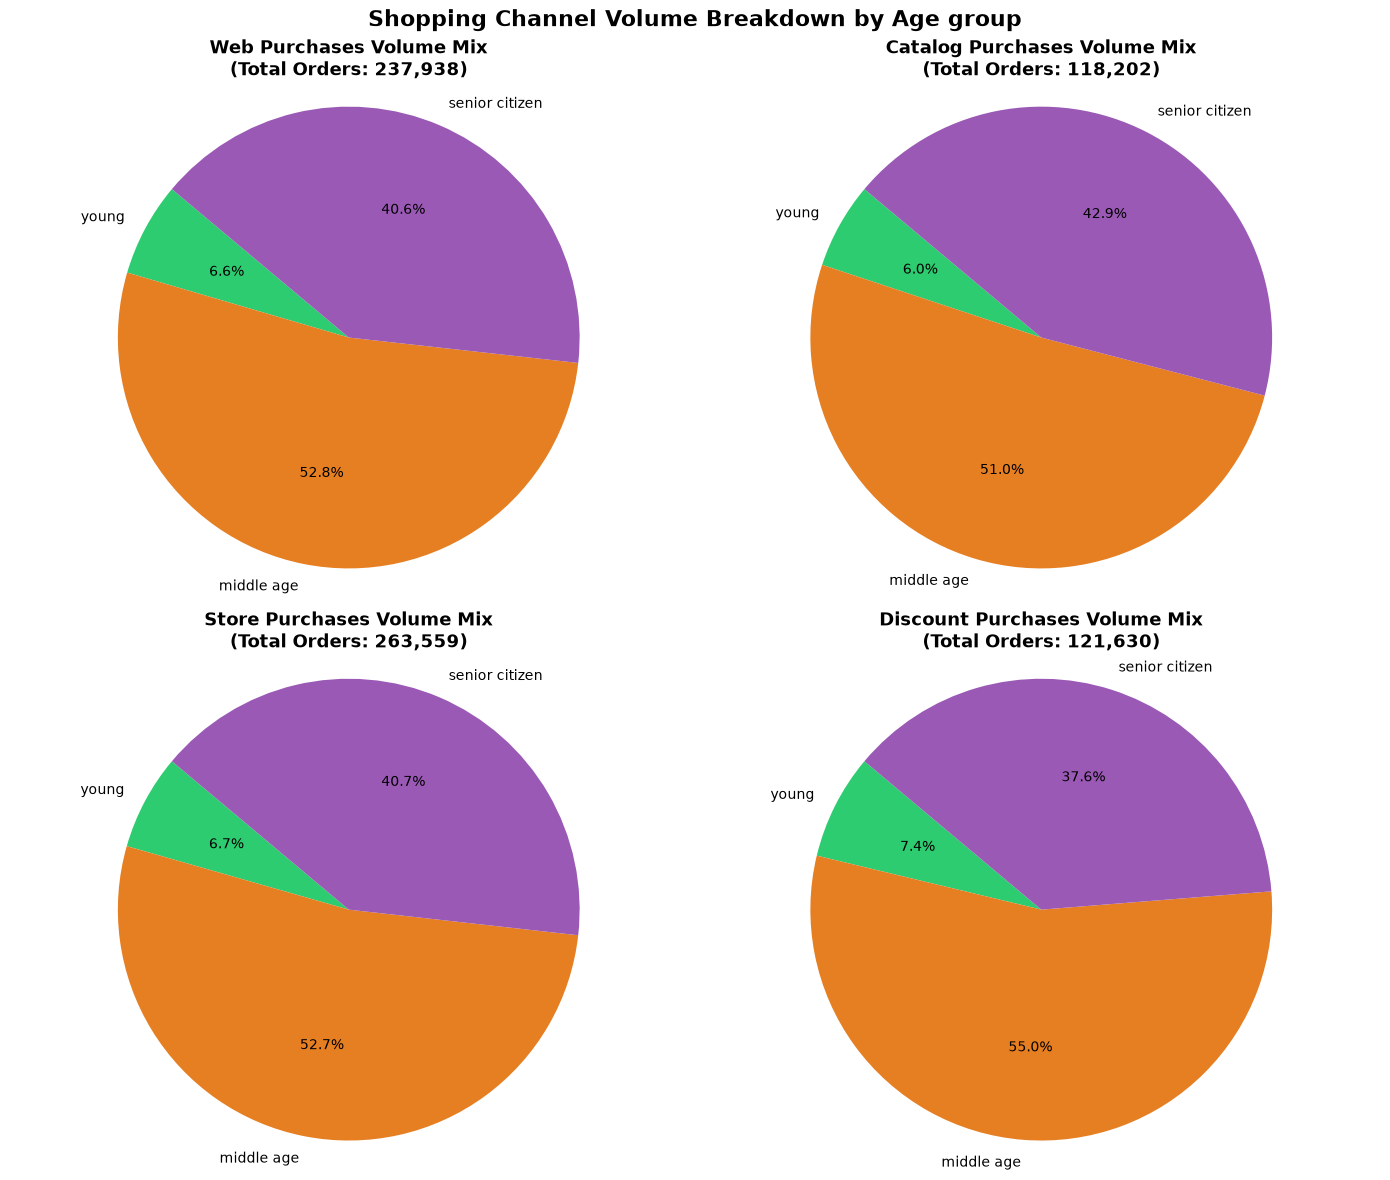

In [73]:
import matplotlib.pyplot as plt

# 1. Define the 4 standard shopping channel columns and clean titles
channel_cols = [
    "Web_Purchase",
    "Catalog_Purchase",
    "Store_Purchase",
    "Discount_Purchase",
]
channel_labels = [
    "Web Purchases",
    "Catalog Purchases",
    "Store Purchases",
    "Discount Purchases",
]

# 2. SELECT YOUR DEMOGRAPHIC FILTER: Change to "Income_Group" if preferred
demographic_col = "Age_group"  # Alternative: "Income_Group"

# 3. Setup a clean 2x2 grid of subplots for the 4 purchase channels
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()  # Flatten the 2x2 matrix grid into a iterable 1D list

# Visual color palette for slices
colors = ["#2ecc71", "#e67e22", "#9b59b6", "#34495e"]

# 4. Loop through each shopping channel and build its customer mix chart
for i, col in enumerate(channel_cols):
    # Sum the total number of orders placed through this channel, grouped by demographic
    channel_volume_mix = marketing_campaign.groupby(
        demographic_col, observed=False
    )[col].sum()

    # Plot the pie chart for this channel
    axes[i].pie(
        channel_volume_mix,
        labels=channel_volume_mix.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=colors[: len(channel_volume_mix)],
        textprops={"fontsize": 10},
    )

    # Title with the channel name and total transaction volume
    total_orders = channel_volume_mix.sum()
    axes[i].set_title(
        f"{channel_labels[i]} Volume Mix\n(Total Orders: {int(total_orders):,})",
        weight="bold",
        fontsize=13,
    )
    axes[i].axis("equal")  # Keeps the pie charts circular

# 5. Overarching title and spacing adjustments
plt.suptitle(
    f"Shopping Channel Volume Breakdown by {demographic_col.replace('_', ' ')}",
    fontsize=16,
    weight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()


In [74]:
marketing_campaign.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kids',
       'Teen', 'Enroll_Date', 'Recency', 'Wine_Spend', 'Fruits_Spend',
       'Meat_Spend', 'Fish_Spend', 'Sweets_Spend', 'Gold_Spend',
       'Discount_Purchase', 'Web_Purchase', 'Catalog_Purchase',
       'Store_Purchase', 'Web_monthly_Visit', 'AcceptedCmp3', 'AcceptedCmp4',
       'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain',
       'Resident', 'children', 'Age', 'Total_Spend', 'Total_Purchase',
       'Age_group', 'Income_group'],
      dtype='str')

In [75]:
marketing_campaign.head(50)

,ID,Year_Birth,Education,Marital_Status,Income,Kids,Teen,Enroll_Date,Recency,Wine_Spend,...,AcceptedCmp2,Response,Complain,Resident,children,Age,Total_Spend,Total_Purchase,Age_group,Income_group
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,0,False,False,Spain,1,39,69,10,middle age,middle_income
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,0,False,False,Spain,2,49,39,3,middle age,low_income
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,0,False,False,Australia,0,46,1512,9,middle age,middle_income
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,0,False,False,Spain,1,48,478,15,middle age,middle_income
4,15815139,1981,Graduation,Unattached,52784.2,1,1,2014-05-20,0,30,...,0,False,False,Canada,2,43,330,8,middle age,middle_income
5,7194200,1977,Master,Married,36353.5,1,0,2014-03-28,99,0,...,0,False,False,Canada,1,47,132,10,middle age,low_income
6,2330269,1960,Basic,Unattached,111080.3,0,0,2013-08-05,14,152,...,0,False,False,Germany,0,64,843,14,senior citizen,high_income
7,12076936,1996,Doctoral,Unattached,55986.3,1,1,2014-02-16,52,80,...,0,False,False,India,2,28,98,10,young,middle_income
8,13223357,1964,Master,Single,67793.7,1,0,2013-01-28,11,5,...,0,False,False,Saudi Arabia,1,60,91,8,senior citizen,middle_income
9,7068405,1968,Graduation,Together,54240.7,1,1,2014-06-29,69,87,...,0,False,False,USA,2,56,251,3,senior citizen,middle_income


In [76]:
import pandas as pd

# 'df' is your modified dataframe
# Replace 'my_folder/my_data.csv' with your actual folder path and file name
marketing_campaign.to_csv('C:\\Users\\HP\\Desktop\\project-Marketing campaign analysis\\marketing_updated.csv', index=False)


# SQL

In [77]:
marketing_campaign.columns = marketing_campaign.columns.str.lower()

In [78]:
marketing_campaign.columns

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kids',
       'teen', 'enroll_date', 'recency', 'wine_spend', 'fruits_spend',
       'meat_spend', 'fish_spend', 'sweets_spend', 'gold_spend',
       'discount_purchase', 'web_purchase', 'catalog_purchase',
       'store_purchase', 'web_monthly_visit', 'acceptedcmp3', 'acceptedcmp4',
       'acceptedcmp5', 'acceptedcmp1', 'acceptedcmp2', 'response', 'complain',
       'resident', 'children', 'age', 'total_spend', 'total_purchase',
       'age_group', 'income_group'],
      dtype='str')

In [10]:
!pip install mysql-connector-python


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import mysql.connector

conn_mysql = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Sid@9358805903"
)
cursor_mysql = conn_mysql.cursor()
print("MySQL connection established!")

MySQL connection established!


In [12]:
cursor_mysql.execute("CREATE DATABASE IF NOT EXISTS marketing_updated;")
print("MySQL database 'marketing_updated' created successfully!")

MySQL database 'marketing_updated' created successfully!


In [13]:
import sqlite3

conn_sqlite = sqlite3.connect("marketing_updated.sqlite")  # Creates a local database file
cursor = conn_sqlite.cursor()
print("SQLite connection established!")

SQLite connection established!


In [14]:
# 1. Select the database context
cursor_mysql.execute("USE marketing_updated;")

# 2. Safely wipe the incomplete/broken table
cursor_mysql.execute("DROP TABLE IF EXISTS marketing_updated;")
print("Cleaned up old table structure.")

# 3. Create a fresh, finalized table with 'age' explicitly included
cursor_mysql.execute("""
    CREATE TABLE marketing_updated (
            id INT PRIMARY KEY,
            year_birth INT,
            age INT,                   -- The missing column MySQL was complaining about
            education VARCHAR(50),
            marital_status VARCHAR(50),
            resident VARCHAR(100),
            income DECIMAL(12, 2),                     
            kids INT,
            teen INT,
            children INT,                     
            enroll_Date DATE,
            recency INT,
            complain INT,                       
            wine_spend DECIMAL(10, 2),
            fruits_spend DECIMAL(10, 2),
            meat_spend DECIMAL(10, 2),
            fish_spend DECIMAL(10, 2),
            sweets_spend DECIMAL(10, 2),
            gold_spend DECIMAL(10, 2),
            total_spend DECIMAL(12, 2),                        
            discount_purchase INT,
            web_purchase INT,
            catalog_purchase INT,
            store_purchase INT,
            total_purchase INT,
            web_monthly_visit INT,                                           
            acceptedcmp1 BOOLEAN,
            acceptedcmp2 BOOLEAN,
            acceptedcmp3 BOOLEAN,
            acceptedcmp4 BOOLEAN,
            acceptedcmp5 BOOLEAN,
            response BOOLEAN,
            age_group VARCHAR(20),
            income_group VARCHAR(20)
    );
""")
conn_mysql.commit()
print("🎉 Fresh table 'marketing_updated' built with all 34 required fields!")


Cleaned up old table structure.
🎉 Fresh table 'marketing_updated' built with all 34 required fields!


In [15]:
import csv
import mysql.connector

csv_file_path = "marketing_updated.csv"

# --- 2. SQL Insert Query ---
insert_query = """
    INSERT INTO marketing_updated (
        id, year_birth, age, education, marital_status, resident, income, 
        kids, teen, children, enroll_Date, recency, complain, 
        wine_spend, fruits_spend, meat_spend, fish_spend, sweets_spend, gold_spend, total_spend, 
        discount_purchase, web_purchase, catalog_purchase, store_purchase, total_purchase, 
        web_monthly_visit, acceptedcmp1, acceptedcmp2, acceptedcmp3, acceptedcmp4, acceptedcmp5, 
        response, age_group, income_group
    ) VALUES (
        %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, 
        %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, 
        %s, %s, %s, %s, %s, %s, %s, %s
    );
"""

# --- 3. Robust Data Cleaning Helpers ---
def clean_bool(val):
    if not val or not str(val).strip():
        return 0
    cleaned = str(val).strip().lower()
    return 1 if cleaned in ['true', '1', 'yes', 'y'] else 0

def clean_int(val):
    if not val or not str(val).strip():
        return None
    cleaned = str(val).strip()
    if cleaned.lower() == 'false': return 0
    if cleaned.lower() == 'true': return 1
    try:
        return int(float(cleaned))
    except ValueError:
        return None

def clean_float(val):
    if not val or not str(val).strip():
        return None
    try:
        return float(val)
    except ValueError:
        return None

# --- 4. Process CSV and Prepare Batch Insertion ---
all_data = []

# Using 'utf-8-sig' strips hidden byte-order marks (BOM) common in Excel exports
with open(csv_file_path, mode='r', encoding='utf-8-sig') as file:
    csv_reader = csv.DictReader(file)
    
    for row in csv_reader:
        # Create a normalized look-up row where keys are lowercased and stripped of whitespace
        clean_row = {k.strip().lower(): v for k, v in row.items() if k is not None}
        
        # Guard clause: Skip rows completely if the core identifier is missing
        record_id = clean_int(clean_row.get('id'))
        if record_id is None:
            continue
            
        values = (
            record_id,
            clean_int(clean_row.get('year_birth')),
            clean_int(clean_row.get('age')),
            clean_row.get('education', '').strip(),
            clean_row.get('marital_status', '').strip(),
            clean_row.get('resident', '').strip(),
            clean_float(clean_row.get('income')),
            clean_int(clean_row.get('kids')),
            clean_int(clean_row.get('teen')),
            clean_int(clean_row.get('children')),
            clean_row.get('enroll_date', '').strip() or None,  # Case-insensitive header match
            clean_int(clean_row.get('recency')),
            clean_bool(clean_row.get('complain')),  
            clean_float(clean_row.get('wine_spend')),
            clean_float(clean_row.get('fruits_spend')),
            clean_float(clean_row.get('meat_spend')),
            clean_float(clean_row.get('fish_spend')),
            clean_float(clean_row.get('sweets_spend')),
            clean_float(clean_row.get('gold_spend')),
            clean_float(clean_row.get('total_spend')),
            clean_int(clean_row.get('discount_purchase')),
            clean_int(clean_row.get('web_purchase')),
            clean_int(clean_row.get('catalog_purchase')),
            clean_int(clean_row.get('store_purchase')),
            clean_int(clean_row.get('total_purchase')),
            clean_int(clean_row.get('web_monthly_visit')),
            clean_bool(clean_row.get('acceptedcmp1')),
            clean_bool(clean_row.get('acceptedcmp2')),
            clean_bool(clean_row.get('acceptedcmp3')),
            clean_bool(clean_row.get('acceptedcmp4')),
            clean_bool(clean_row.get('acceptedcmp5')),
            clean_bool(clean_row.get('response')),
            clean_row.get('age_group', '').strip(),
            clean_row.get('income_group', '').strip()
        )
        all_data.append(values)

# --- 5. Execute Block ---
if all_data:
    print(f"📦 Processing {len(all_data)} rows...")
    try:
        cursor_mysql.executemany(insert_query, all_data)
        conn_mysql.commit()
        print("🚀 Success! Data successfully cleaned and inserted into MySQL.")
    except mysql.connector.Error as err:
        print(f"❌ Database error encountered: {err}")
        conn_mysql.rollback()
else:
    print("⚠️ No valid records with valid IDs were found in the CSV file.")




📦 Processing 56000 rows...
🚀 Success! Data successfully cleaned and inserted into MySQL.


#SQL QUERIES 


query1 --->  age and income wise customers response rate 

In [16]:
query1 = """
    SELECT age_group, income_group, COUNT(*) AS total_customers,
    -- Calculate response rate for Campaign 1 (multiplied by 100 for a clean percentage)
    ROUND(AVG(acceptedcmp1) * 100, 2) AS campaign_1_response_rate_pct,
    -- Calculate response rate for Campaign 2
    ROUND(AVG(acceptedcmp2) * 100, 2) AS campaign_2_response_rate_pct,
    -- Calculate response rate for Campaign 3
    ROUND(AVG(acceptedcmp3) * 100, 2) AS campaign_3_response_rate_pct,
    -- Calculate response rate for Campaign 4
    ROUND(AVG(acceptedcmp4) * 100, 2) AS campaign_4_response_rate_pct,
    -- Calculate response rate for Campaign 5
    ROUND(AVG(acceptedcmp5) * 100, 2) AS campaign_5_response_rate_pct,
    -- Calculate response rate for the Final Response campaign
    ROUND(AVG(response) * 100, 2) AS final_response_rate_pct
FROM 
    marketing_updated
GROUP BY 
    age_group, 
    income_group
ORDER BY 
    age_group ASC, 
    income_group ASC;
"""



cursor_mysql.execute(query1)
result1 = cursor_mysql.fetchall()
print("Hottest and Coldest Days:", result1)


Hottest and Coldest Days: [('middle age', 'high_income', 3387, Decimal('23.15'), Decimal('2.33'), Decimal('8.03'), Decimal('9.03'), Decimal('9.60'), Decimal('27.02')), ('middle age', 'low_income', 14067, Decimal('6.05'), Decimal('0.80'), Decimal('4.96'), Decimal('2.75'), Decimal('1.32'), Decimal('6.91')), ('middle age', 'middle_income', 13174, Decimal('15.77'), Decimal('1.65'), Decimal('6.92'), Decimal('7.10'), Decimal('5.59'), Decimal('17.14')), ('senior citizen', 'high_income', 3493, Decimal('25.16'), Decimal('2.43'), Decimal('6.81'), Decimal('9.91'), Decimal('10.79'), Decimal('29.00')), ('senior citizen', 'low_income', 7562, Decimal('8.54'), Decimal('1.02'), Decimal('5.05'), Decimal('3.64'), Decimal('1.86'), Decimal('8.41')), ('senior citizen', 'middle_income', 10288, Decimal('18.21'), Decimal('1.93'), Decimal('7.33'), Decimal('7.25'), Decimal('6.67'), Decimal('19.68')), ('young', 'high_income', 397, Decimal('22.42'), Decimal('2.27'), Decimal('10.83'), Decimal('8.06'), Decimal('6.30

query2 ---> age and income group wise spends on each product

In [17]:
query2 = """
SELECT age_group,
    income_group,
    COUNT(*) AS total_customers,
    -- Average spending across individual categories
    ROUND(AVG(wine_spend), 2) AS avg_wine_spend,
    ROUND(AVG(fruits_spend), 2) AS avg_fruits_spend,
    ROUND(AVG(meat_spend), 2) AS avg_meat_spend,
    ROUND(AVG(fish_spend), 2) AS avg_fish_spend,
    ROUND(AVG(sweets_spend), 2) AS avg_sweets_spend,
    ROUND(AVG(gold_spend), 2) AS avg_gold_spend,
    -- Overall average total spending for the segment
    ROUND(AVG(total_spend), 2) AS avg_overall_spend
FROM 
    marketing_updated
GROUP BY 
    age_group, 
    income_group
ORDER BY 
    avg_overall_spend DESC; 
"""

cursor_mysql.execute(query2)
result2 = cursor_mysql.fetchall()
print("Average Spending by Segment:", result2)


Average Spending by Segment: [('senior citizen', 'high_income', 3493, Decimal('548.31'), Decimal('41.43'), Decimal('478.46'), Decimal('108.76'), Decimal('56.62'), Decimal('66.43'), Decimal('1300.02')), ('middle age', 'high_income', 3387, Decimal('485.63'), Decimal('34.06'), Decimal('448.18'), Decimal('95.87'), Decimal('46.84'), Decimal('58.51'), Decimal('1169.08')), ('young', 'high_income', 397, Decimal('480.04'), Decimal('30.60'), Decimal('408.08'), Decimal('92.32'), Decimal('40.34'), Decimal('50.89'), Decimal('1102.25')), ('senior citizen', 'middle_income', 10288, Decimal('354.65'), Decimal('24.24'), Decimal('359.36'), Decimal('71.71'), Decimal('33.18'), Decimal('48.21'), Decimal('891.35')), ('middle age', 'middle_income', 13174, Decimal('287.48'), Decimal('17.87'), Decimal('315.48'), Decimal('60.41'), Decimal('25.40'), Decimal('42.72'), Decimal('749.35')), ('young', 'middle_income', 1618, Decimal('239.30'), Decimal('14.55'), Decimal('293.24'), Decimal('50.66'), Decimal('21.48'), Dec

query3 ---> age and income wise monthly web visits 

In [18]:
query3 = """
SELECT 
    age_group,
    income_group,
    COUNT(*) AS total_customers,
    -- Calculate average monthly website visits
    ROUND(AVG(web_monthly_visit), 2) AS avg_monthly_web_visits
FROM 
    marketing_updated
GROUP BY 
    age_group, 
    income_group
ORDER BY 
    avg_monthly_web_visits DESC;
"""    

cursor_mysql.execute(query3)
result3 = cursor_mysql.fetchall()
print("Average Monthly Website Visits by Segment:", result3)


Average Monthly Website Visits by Segment: [('young', 'low_income', 2014, Decimal('6.18')), ('middle age', 'low_income', 14067, Decimal('5.97')), ('senior citizen', 'low_income', 7562, Decimal('5.74')), ('young', 'middle_income', 1618, Decimal('5.06')), ('middle age', 'middle_income', 13174, Decimal('4.93')), ('senior citizen', 'middle_income', 10288, Decimal('4.70')), ('young', 'high_income', 397, Decimal('4.07')), ('middle age', 'high_income', 3387, Decimal('4.03')), ('senior citizen', 'high_income', 3493, Decimal('3.75'))]


query4 ---->customer education level and income wise avg. spend ,web visit and participation in campaign 

In [19]:
query4 = """
SELECT 
    education,
    COUNT(*) AS customer_count,
    ROUND(AVG(income), 2) AS avg_income,
    ROUND(AVG(total_spend), 2) AS avg_total_spend,
    ROUND(AVG(web_monthly_visit), 2) AS avg_monthly_web_visits,
    ROUND(AVG(response) * 100, 2) AS final_campaign_conversion_pct
FROM 
    marketing_updated
GROUP BY 
    education
ORDER BY 
    avg_total_spend DESC;
"""
cursor_mysql.execute(query4)
result4 = cursor_mysql.fetchall()
print("Average Spending and Conversion by Education Level:", result4)

Average Spending and Conversion by Education Level: [('Graduation', 22741, Decimal('64675.94'), Decimal('747.35'), Decimal('4.90'), Decimal('17.30')), ('Master', 16496, Decimal('54150.72'), Decimal('598.88'), Decimal('5.26'), Decimal('13.34')), ('Doctoral', 12581, Decimal('53762.13'), Decimal('575.67'), Decimal('5.36'), Decimal('13.85')), ('Basic', 4182, Decimal('39616.26'), Decimal('416.46'), Decimal('5.69'), Decimal('9.28'))]


query5 ----> response and complaint percentage customer age and income wise 

In [20]:
query5 = """
SELECT age_group, income_group,
    COUNT(*) AS total_customers,
    -- Campaign Response Rate Calculation
    ROUND(AVG(response) * 100, 2) AS response_rate_percent,
    -- Customer Complaint Rate Calculation
    ROUND(AVG(complain) * 100, 2) AS complaint_rate_percent
FROM 
    marketing_updated
GROUP BY 
    age_group, 
    income_group
ORDER BY 
    age_group ASC, 
    income_group ASC;
"""


cursor_mysql.execute(query5)
result5 = cursor_mysql.fetchall()
print(result5)

[('middle age', 'high_income', 3387, Decimal('27.02'), Decimal('0.89')), ('middle age', 'low_income', 14067, Decimal('6.91'), Decimal('0.55')), ('middle age', 'middle_income', 13174, Decimal('17.14'), Decimal('1.03')), ('senior citizen', 'high_income', 3493, Decimal('29.00'), Decimal('0.74')), ('senior citizen', 'low_income', 7562, Decimal('8.41'), Decimal('0.61')), ('senior citizen', 'middle_income', 10288, Decimal('19.68'), Decimal('0.78')), ('young', 'high_income', 397, Decimal('24.18'), Decimal('1.01')), ('young', 'low_income', 2014, Decimal('5.81'), Decimal('0.65')), ('young', 'middle_income', 1618, Decimal('14.40'), Decimal('0.93'))]


In [30]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set page layout configuration
st.set_page_config(
    page_title="Marketing Analytics Engine",
    layout="wide",
    initial_sidebar_state="expanded"
)

# -----------------------------------------------------------------------------
# Data Loading Engine (Cached)
# -----------------------------------------------------------------------------
@st.cache_data
def load_data(file_path="marketing_updated.csv"):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Could not locate '{file_path}' in your current workspace directory.")
    
    # Read file using utf-8-sig to clear hidden BOM artifacts from Excel
    df = pd.read_csv(file_path, encoding='utf-8-sig')
    # Standardize column headers to lowercase to avoid indexing errors
    df.columns = df.columns.str.strip().str.lower()
    return df

try:
    df = load_data("marketing_updated.csv")
except Exception as e:
    st.error(f"❌ Error loading dataset: {e}")
    st.info("💡 Ensure 'marketing_updated.csv' is placed inside this exact project workspace directory.")
    st.stop()

# -----------------------------------------------------------------------------
# Sidebar Navigation Hub & Global Interactivity Controls
# -----------------------------------------------------------------------------
st.sidebar.title("App Navigation")
app_page = st.sidebar.radio(
    "Go To Page:",
    [
        "Page 1: Demographics Distribution",
        "Page 2: Product Expenditures",
        "Page 3: Engagement & Campaigns",
        "Page 4: Creator Info"
    ]
)

# Shared Interactive Radio Filters for Page 2 and Page 3
selected_age_filter = "All"
selected_inc_filter = "All"

if app_page in ["Page 2: Product Expenditures", "Page 3: Engagement & Campaigns"]:
    st.sidebar.markdown("---")
    st.sidebar.subheader("🎯 Live Dashboard Sub-segmentation Filters")
    
    # Age Group Radio Configuration
    if 'age_group' in df.columns:
        age_options = ["All"] + sorted(list(df['age_group'].dropna().unique()))
        selected_age_filter = st.sidebar.radio("Select Target Age Group:", age_options, key="global_age_radio")
    
    # Income Group Radio Configuration
    if 'income_group' in df.columns:
        inc_options = ["All"] + sorted(list(df['income_group'].dropna().unique()))
        selected_inc_filter = st.sidebar.radio("Select Target Income Group:", inc_options, key="global_inc_radio")

# -----------------------------------------------------------------------------
# PAGE 1: DEMOGRAPHICS DISTRIBUTION
# -----------------------------------------------------------------------------
if app_page == "Page 1: Demographics Distribution":
    st.title("👥 Page 1: Customer Demographics Profile Distribution")
    st.markdown("Analyze baseline cohort volumes and isolate target profile attributes.")
    
    # Visual Chart Breakdowns Row
    c1, c2, c3 = st.columns(3)
    
    with c1:
        st.subheader("Age Group Distribution")
        if 'age_group' in df.columns:
            age_counts = df['age_group'].value_counts().reset_index()
            age_counts.columns = ['Age Group', 'Headcount']
            fig, ax = plt.subplots(figsize=(5, 4))
            sns.barplot(data=age_counts, x='Age Group', y='Headcount', palette="Blues_d", ax=ax)
            plt.xticks(rotation=15)
            st.pyplot(fig)
        else:
            st.warning("'age_group' column missing.")

    with c2:
        st.subheader("Income Group Distribution")
        if 'income_group' in df.columns:
            inc_counts = df['income_group'].value_counts().reset_index()
            inc_counts.columns = ['Income Group', 'Headcount']
            fig, ax = plt.subplots(figsize=(5, 4))
            sns.barplot(data=inc_counts, x='Income Group', y='Headcount', palette="Greens_d", ax=ax)
            plt.xticks(rotation=15)
            st.pyplot(fig)
        else:
            st.warning("'income_group' column missing.")

    with c3:
        st.subheader("Children Distribution")
        if 'children' in df.columns:
            child_counts = df['children'].value_counts().reset_index()
            child_counts.columns = ['Children Count', 'Headcount']
            fig, ax = plt.subplots(figsize=(5, 4))
            sns.barplot(data=child_counts, x='Children Count', y='Headcount', palette="Purples_d", ax=ax)
            st.pyplot(fig)
        elif 'kids' in df.columns:
            # Fallback if the dataset splits it under 'kids'
            kid_counts = df['kids'].value_counts().reset_index()
            kid_counts.columns = ['Kids Count', 'Headcount']
            fig, ax = plt.subplots(figsize=(5, 4))
            sns.barplot(data=kid_counts, x='Kids Count', y='Headcount', palette="Purples_d", ax=ax)
            st.pyplot(fig)
        else:
            st.warning("'children' column missing.")

    st.markdown("---")
    st.subheader("🔍 Dynamic Profile Expansion Section")
    
    f1, f2, f3 = st.columns(3)
    with f1:
        p1_age_opts = ["All"] + sorted(list(df['age_group'].dropna().unique())) if 'age_group' in df.columns else ["All"]
        sel_age = st.selectbox("Filter Data Table by Age Group:", p1_age_opts)
    with f2:
        p1_inc_opts = ["All"] + sorted(list(df['income_group'].dropna().unique())) if 'income_group' in df.columns else ["All"]
        sel_inc = st.selectbox("Filter Data Table by Income Group:", p1_inc_opts)
    with f3:
        child_col_name = 'children' if 'children' in df.columns else ('kids' if 'kids' in df.columns else None)
        if child_col_name:
            p1_child_opts = ["All"] + sorted([str(int(x)) for x in df[child_col_name].dropna().unique()])
            sel_child = st.selectbox("Filter Data Table by Children Count:", p1_child_opts)
        else:
            sel_child = "All"

    # Apply Filters to Table Expansion
    filt_df = df.copy()
    if sel_age != "All":
        filt_df = filt_df[filt_df['age_group'] == sel_age]
    if sel_inc != "All":
        filt_df = filt_df[filt_df['income_group'] == sel_inc]
    if sel_child != "All" and child_col_name:
        filt_df = filt_df[filt_df[child_col_name] == int(sel_child)]

    with st.expander(f"📋 Expand Customer Base Logbook ({len(filt_df)} matching lines found)", expanded=True):
        st.dataframe(filt_df, use_container_width=True)

# -----------------------------------------------------------------------------
# PAGE 2: PRODUCT EXPENDITURES (FILTERED VIA SIDEBAR RADIOS)
# -----------------------------------------------------------------------------
elif app_page == "Page 2: Product Expenditures":
    st.title("🛍️ Page 2: Product Spending Profiles & Total Wallet Analysis")
    st.markdown(f"**Current Segment Focus:** Age Group = `{selected_age_filter}` | Income Group = `{selected_inc_filter}`")

    # Apply Sidebar Radio Filter Selections to Dataset
    p2_df = df.copy()
    if selected_age_filter != "All":
        p2_df = p2_df[p2_df['age_group'] == selected_age_filter]
    if selected_inc_filter != "All":
        p2_df = p2_df[p2_df['income_group'] == selected_inc_filter]

    spend_cols = ['wine_spend', 'fruits_spend', 'meat_spend', 'fish_spend', 'sweets_spend', 'gold_spend']
    valid_spends = [c for c in spend_cols if c in p2_df.columns]

    if len(p2_df) == 0:
        st.warning("⚠️ No customer records match the cross-selected segment criteria in the sidebar.")
    elif valid_spends:
        # Segment KPI Summaries
        total_revenue = p2_df['total_spend'].sum() if 'total_spend' in p2_df.columns else p2_df[valid_spends].sum().sum()
        avg_spend = p2_df['total_spend'].mean() if 'total_spend' in p2_df.columns else p2_df[valid_spends].sum(axis=1).mean()

        m1, m2, m3 = st.columns(3)
        m1.metric("Segment Record Headcount", f"{len(p2_df):,}")
        m2.metric("Segment Total Spend", f"${total_revenue:,.2f}")
        m3.metric("Segment Avg Household Spend", f"${avg_spend:,.2f}")

        st.markdown("---")
        
        # Segment product wise average distribution chart
        st.subheader("📦 Mean Product Expenditure Categories Breakdown (Filtered Segment)")
        fig, ax = plt.subplots(figsize=(10, 3.5))
        mean_vals = p2_df[valid_spends].mean().sort_values(ascending=False)
        sns.barplot(x=mean_vals.values, y=[c.replace('_',' ').title() for c in mean_vals.index], palette="rocket", ax=ax)
        ax.set_xlabel("Mean Ticket Value ($)")
        st.pyplot(fig)

        # Segment level granular data matrix view
        st.markdown("---")
        st.subheader("📋 Segment Transactional Spend Logbook")
        view_cols = ['id'] + valid_spends + (['total_spend'] if 'total_spend' in p2_df.columns else [])
        st.dataframe(p2_df[[c for c in view_cols if c in p2_df.columns]], use_container_width=True)
    else:
        st.error("No valid spend data metric vectors found in data headers structure.")

# -----------------------------------------------------------------------------
# PAGE 3: ENGAGEMENT & CAMPAIGNS (FILTERED VIA SIDEBAR RADIOS)
# -----------------------------------------------------------------------------
elif app_page == "Page 3: Engagement & Campaigns":
    st.title("🎯 Page 3: Conversion Flags, Campaigns & Retention Insights")
    st.markdown(f"**Current Segment Focus:** Age Group = `{selected_age_filter}` | Income Group = `{selected_inc_filter}`")

    # Apply Sidebar Radio Filter Selections to Dataset
    p3_df = df.copy()
    if selected_age_filter != "All":
        p3_df = p3_df[p3_df['age_group'] == selected_age_filter]
    if selected_inc_filter != "All":
        p3_df = p3_df[p3_df['income_group'] == selected_inc_filter]

    if len(p3_df) == 0:
        st.warning("⚠️ No customer records match the cross-selected segment criteria in the sidebar.")
    else:
        # Segment behavioral highlights
        k1, k2, k3, k4 = st.columns(4)
        k1.metric("Segment Record Headcount", f"{len(p3_df):,}")
        k2.metric("Segment Avg Monthly Web Visits", f"{p3_df['web_monthly_visit'].mean():.2f}" if 'web_monthly_visit' in p3_df.columns else "N/A")
        k3.metric("Segment Avg Total Spend", f"${p3_df['total_spend'].mean():,.2f}" if 'total_spend' in p3_df.columns else "N/A")
        k4.metric("Segment Avg Campaign Response Rate", f"{p3_df['response'].mean() * 100:.2f}%" if 'response' in p3_df.columns else "N/A")

        st.markdown("---")# Campaign Performance Segment Split
        st.subheader("📢 Campaign Performance & Opt-in Tracking (Filtered Segment)")
        cmp_cols = ['acceptedcmp1', 'acceptedcmp2', 'acceptedcmp3', 'acceptedcmp4',
                     'acceptedcmp5', 'response']
        valid_cmps = [c for c in cmp_cols if c in p3_df.columns]
        if valid_cmps:
            cmp_totals = p3_df[valid_cmps].sum().to_frame(name="Total Opt-ins")
            cmp_totals["Conversion Rate (%)"] = (cmp_totals["Total Opt-ins"] / len(p3_df)) * 100
            cmp_totals.index = [c.replace('acceptedcmp', 'Campaign ').title() for c in cmp_totals.index]
            c_left, c_right = st.columns([1, 1.5])
            with c_left:
                st.dataframe(cmp_totals.style.format({"Conversion Rate (%)": "{:.2f}%"}))
            with c_right:
                fig, ax = plt.subplots(figsize=(6, 3.2))
                sns.barplot(x=cmp_totals["Conversion Rate (%)"].values, y=cmp_totals.index, palette="viridis", ax=ax)
                ax.set_xlabel("Conversion Rate (%)")
                st.pyplot(fig)
        else:
            st.warning("No campaign column metrics discovered in layout.")
        st.markdown("---")
        st.subheader("📋 Segment Engagement Matrix Data")
        behavioral_cols = ['id', 'recency', 'complain', 'web_monthly_visit'] + valid_cmps
        st.dataframe(p3_df[[c for c in behavioral_cols if c in p3_df.columns]], use_container_width=True)

#----------------------------------------------------------------------------PAGE 4: CREATOR INFO-----------------------------------------------------------------------------
elif app_page == "Page 4: Creator Info":
        st.title("🛠️ Page 4: Architecture Creator Pipeline Profile")
        with st.container(border=True):
             st.subheader("🎓 Professional Structural Profile")
        col_img, col_txt = st.columns([1, 5])
        with col_img:
            st.markdown("## 👨‍💻")
        with col_txt:
            st.markdown("### Sidharath Singh")
            st.write("✨ Domain Specialization: Data Science Engineering")
            st.write("📚 Academic Suite: Data Science Course Pipeline Project Portfolio")
        st.markdown("---")
        st.subheader("⚙️ Technical System Architecture Metadata")
        info_col1, info_col2 = st.columns(2)
        with info_col1:
            st.info("💻 Front-End Layout Interface: Multi-page Streamlit Dashboard Module Layout Configuration with dynamic global side-filters.")
            st.success("📦 Backend Cache Configuration: Performance @st.cache_data safely optimization handling rapid UI rendering calculations.")
        with info_col2:
            st.metric("Total Managed Columns Feature Metrics Count", f"{len(df.columns)}")
            st.metric("Total Scaled Relational File Records", f"{len(df):,}")                 


2026-09-10 12:43:25.668 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-10 12:43:25.672 No runtime found, using MemoryCacheStorageManager
2026-09-10 12:43:25.700 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-10 12:43:25.703 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-10 12:43:25.705 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-10 12:43:25.707 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-10 12:43:25.709 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-10 12:43:25.711 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-10 12:43:25.712 Thread 'MainThread':

C:\Users\HP\AppData\Local\Temp\ipykernel_17860\3364516763.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_counts, x='Age Group', y='Headcount', palette="Blues_d", ax=ax)
2026-09-10 12:43:26.012 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-10 12:43:26.336 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-10 12:43:26.338 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-10 12:43:26.341 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-10 12:43:26.344 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-10 12:43:26.350 Thread 'Mai